# Tarea Modelo: Tormenta geomagnética del 7 al 10 de marzo de 2012

Este notebook analiza el evento del **7 al 10 de marzo de 2012** usando datos descargados mediante la interfaz HAPI.

- **Período calmo (línea base):** 5 y 6 de marzo (Kp < 5).
- **Período de tormenta:** 7 al 10 de marzo (Kp ≥ 5, Dst < −50 nT).
- La tormenta fue producida por una CME halo registrada el 5 de marzo que impactó la Tierra el 7 de marzo.

# Metodologia

El notebook se divide en dos capas. La primera capa trabaja con los productos observacionales ya descargados a CSV y JSON. La segunda capa deja un punto de entrada controlado para resultados CCMC.




In [1]:
!pip install numpy --quiet

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

# Ventana extendida: días calmos 5-6 de marzo + días de tormenta 7-10 de marzo
EVENT_START = pd.Timestamp("2012-03-05T00:00:00Z")
EVENT_STOP  = pd.Timestamp("2012-03-11T00:00:00Z")

# Umbrales de tormenta geomagnética
KP_STORM_THRESHOLD  = 5.0  
DST_STORM_THRESHOLD = -50.0  # Dst < -50 nT confirma tormenta geomagnética

DATA_DIR = Path("data/hapi_tareamodelo")
CCMC_DIR = Path("data/ccmc")

print(f"Ventana del evento : {EVENT_START} -> {EVENT_STOP}")
print(f"Umbrales de tormenta: Kp >= {KP_STORM_THRESHOLD}, Dst < {DST_STORM_THRESHOLD} nT")
print(f"Directorio de datos HAPI: {DATA_DIR.resolve()}")

Ventana del evento : 2012-03-05 00:00:00+00:00 -> 2012-03-11 00:00:00+00:00
Umbrales de tormenta: Kp >= 5.0, Dst < -50.0 nT
Directorio de datos HAPI: /Volumes/T7/tarea3-astroparticulas/data/hapi_tareamodelo




El analisis usa primero los archivos locales. Si algun producto no esta disponible, el notebook lo marca como faltante y sigue con el resto.


In [3]:
expected_products = [
    # Índices geomagnéticos
    {"slug": "dst_final",              "label": "Dst",              "group": "indices",     "required": True},
    {"slug": "noaa_kp_observed",       "label": "Kp observado",     "group": "indices",     "required": True},
    # Viento solar – plasma y campo magnético (SWPC/ACE via ISWA)
    {"slug": "swpc_rtsw_plasma",       "label": "Plasma SWPC",      "group": "solar_wind",  "required": True},
    {"slug": "swpc_rtsw_mag",          "label": "Campo mag. SWPC",  "group": "solar_wind",  "required": True},
    # Viento solar de alta resolución (OMNI 5 min)
    {"slug": "omni_hro2_5min",         "label": "OMNI HRO2 5 min", "group": "solar_wind",  "required": True},
    # Partículas energéticas ACE (AC_K0_EPM no disponible para 2012;  no disponible)
    {"slug": "ac_k0_epm",              "label": "ACE EPM (K0)",     "group": "energetic",   "required": False},
    # Magnetómetros terrestres INTERMAGNET
    {"slug": "intermagnet_abk_field_magnitude", "label": "INTERMAGNET ABK", "group": "ground", "required": False},
    {"slug": "intermagnet_mea_field_magnitude", "label": "INTERMAGNET MEA", "group": "ground", "required": False},
    {"slug": "intermagnet_sjg_field_magnitude", "label": "INTERMAGNET SJG", "group": "ground", "required": True},
    {"slug": "intermagnet_hua_field_magnitude", "label": "INTERMAGNET HUA", "group": "ground", "required": False},
    # Coronógrafo solar
    {"slug": "lasco_c3_urls",          "label": "LASCO C3 URLs",    "group": "imagery",     "required": False},
]

availability_rows = []
for item in expected_products:
    csv_path = DATA_DIR / f"{item['slug']}.csv"
    metadata_path = DATA_DIR / f"{item['slug']}.metadata.json"
    # ac_k0_epm no cubre el período 2012; se marca como fuera de rango
    out_of_range = item["slug"] == "ac_k0_epm"
    availability_rows.append({
        "slug": item["slug"],
        "label": item["label"],
        "group": item["group"],
        "required": item["required"],
        "csv_exists": csv_path.exists() and not out_of_range,
        "out_of_range": out_of_range,
        "csv_path": str(csv_path),
    })

availability = pd.DataFrame(availability_rows)
display(availability[["slug", "label", "group", "required", "csv_exists", "out_of_range"]])

missing_required = availability.loc[availability["required"] & ~availability["csv_exists"], "slug"].tolist()
if missing_required:
    print("Faltan productos requeridos:", ", ".join(missing_required))
else:
    print("Todos los productos requeridos están disponibles.")

,slug,label,group,required,csv_exists,out_of_range
0,dst_final,Dst,indices,True,True,False
1,noaa_kp_observed,Kp observado,indices,True,True,False
2,swpc_rtsw_plasma,Plasma SWPC,solar_wind,True,True,False
3,swpc_rtsw_mag,Campo mag. SWPC,solar_wind,True,True,False
4,omni_hro2_5min,OMNI HRO2 5 min,solar_wind,True,True,False
5,ac_k0_epm,ACE EPM (K0),energetic,False,False,True
6,intermagnet_abk_field_magnitude,INTERMAGNET ABK,ground,False,True,False
7,intermagnet_mea_field_magnitude,INTERMAGNET MEA,ground,False,True,False
8,intermagnet_sjg_field_magnitude,INTERMAGNET SJG,ground,True,True,False
9,intermagnet_hua_field_magnitude,INTERMAGNET HUA,ground,False,True,False


Todos los productos requeridos están disponibles.


# Analisis de Datos Observacionales

A partir de aqui el notebook trabaja con los archivos ya exportados. 


In [4]:
def load_csv(slug):
    path = DATA_DIR / f"{slug}.csv"
    if not path.exists():
        return None
    frame = pd.read_csv(path, parse_dates=["Time"])
    frame["Time"] = pd.to_datetime(frame["Time"], utc=True)
    frame = frame.set_index("Time").sort_index()
    return frame


def load_metadata(slug):
    path = DATA_DIR / f"{slug}.metadata.json"
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


# Cargar todos los slugs con CSV disponible (excepto los marcados fuera de rango)
slugs_to_load = availability.loc[
    availability["csv_exists"] & ~availability["out_of_range"], "slug"
]

datasets = {}
loaded_rows = []

for slug in slugs_to_load:
    frame = load_csv(slug)
    if frame is None:
        continue
    datasets[slug] = frame
    loaded_rows.append({
        "slug": slug,
        "rows": len(frame),
        "columns": ", ".join(frame.columns),
        "start": frame.index.min(),
        "stop": frame.index.max(),
    })

loaded_summary = pd.DataFrame(loaded_rows).sort_values("slug").reset_index(drop=True)
display(loaded_summary)

,slug,rows,columns,start,stop
0,dst_final,144,Dst,2012-03-05 00:00:00+00:00,2012-03-10 23:00:00+00:00
1,intermagnet_abk_field_magnitude,8640,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-10 23:59:00+00:00
2,intermagnet_hua_field_magnitude,8640,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-10 23:59:00+00:00
3,intermagnet_mea_field_magnitude,8640,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-10 23:59:00+00:00
4,intermagnet_sjg_field_magnitude,8640,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-10 23:59:00+00:00
5,lasco_c3_urls,314,url,2012-03-05 00:06:06+00:00,2012-03-07 23:56:39+00:00
6,noaa_kp_observed,48,Kp_observed,2012-03-05 00:00:00+00:00,2012-03-10 21:00:00+00:00
7,omni_hro2_5min,1728,"F, BZ_GSM, flow_speed, Vx, Vy, Vz, proton_dens...",2012-03-05 00:00:00+00:00,2012-03-10 23:55:00+00:00
8,swpc_rtsw_mag,8640,"B_x, B_y, B_z, B_t",2012-03-05 00:00:00+00:00,2012-03-10 23:59:00+00:00
9,swpc_rtsw_plasma,8640,"ProtonDensity, BulkSpeed, IonTemperature",2012-03-05 00:00:00+00:00,2012-03-10 23:59:00+00:00


## Selección del evento y criterios de tormenta

Una **tormenta geomagnética** se identifica cuando se cumplen simultáneamente dos condiciones:
- **Kp ≥ 5**: el índice planetario de actividad geomagnética alcanza nivel de tormenta moderada o superior.
- **Dst < −50 nT**: el índice ecuatorial de perturbación confirma una depresión anular sostenida.

Para el evento del 5 al 10 de marzo de 2012:
- Los **días 5 y 6 de marzo** son días **calmos** (Kp < 5), útiles como línea base de referencia.
- Los **días 7 al 10 de marzo** corresponden al **período de tormenta**, con Dst mínimo alrededor de −143 nT y Kp máximo de 7.

La tormenta fue desencadenada por una **eyección de masa coronal (CME) de tipo halo** registrada el 5 de marzo. 




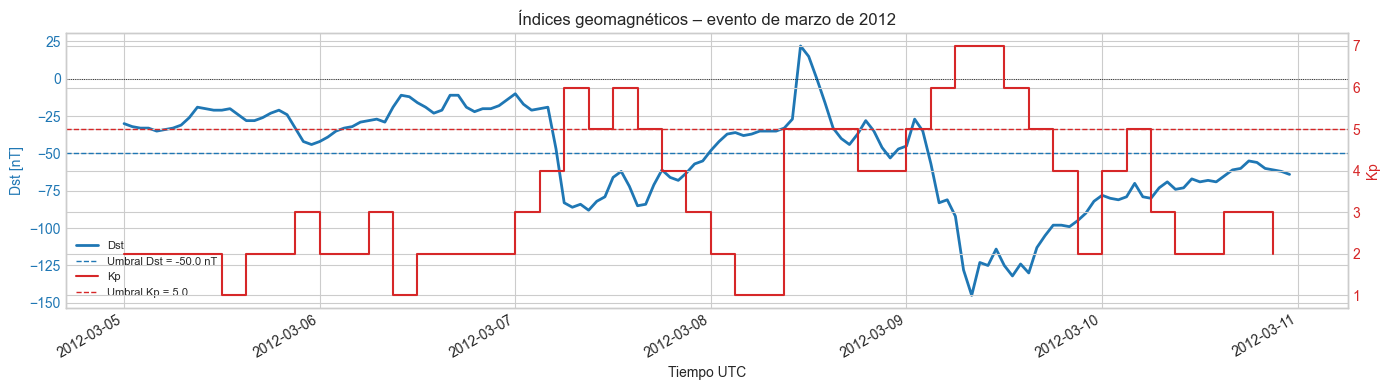

In [5]:
dst = datasets.get("dst_final")
kp  = datasets.get("noaa_kp_observed")

fig, ax1 = plt.subplots(figsize=(14, 4))

if dst is not None:
    ax1.plot(dst.index, dst["Dst"], color="tab:blue", linewidth=2, label="Dst")
    ax1.axhline(DST_STORM_THRESHOLD, color="tab:blue", linewidth=1, linestyle="--",
                label=f"Umbral Dst = {DST_STORM_THRESHOLD} nT")
    ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax1.set_ylabel("Dst [nT]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
if kp is not None:
    kp_hourly = kp["Kp_observed"].resample("1h").ffill()
    ax2.step(kp_hourly.index, kp_hourly, where="post", color="tab:red", linewidth=1.5, label="Kp")
    ax2.axhline(KP_STORM_THRESHOLD, color="tab:red", linewidth=1, linestyle="--",
                label=f"Umbral Kp = {KP_STORM_THRESHOLD}")
    ax2.set_ylabel("Kp", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=8)

ax1.set_title("Índices geomagnéticos – evento de marzo de 2012")
ax1.set_xlabel("Tiempo UTC")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/1216417638.py:38: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Volumes/T7/tarea3-astroparticulas/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


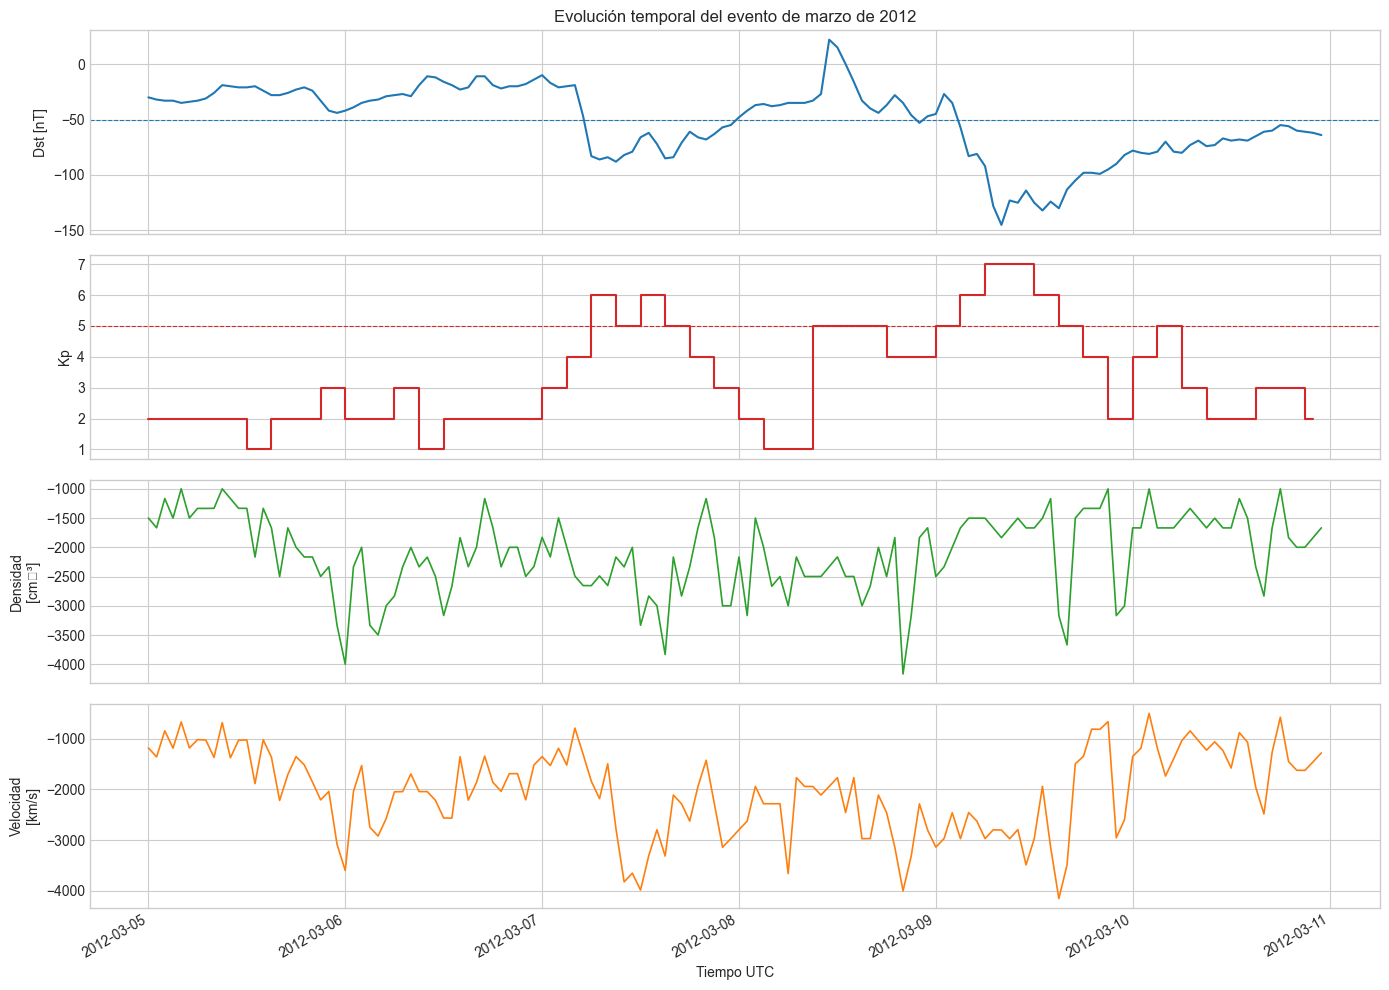

In [6]:
analysis_hourly = pd.DataFrame(
    index=pd.date_range(EVENT_START, EVENT_STOP, freq="1h", inclusive="left")
)

if dst is not None:
    analysis_hourly["Dst"] = dst["Dst"].resample("1h").mean()
if kp is not None:
    analysis_hourly["Kp"] = kp["Kp_observed"].resample("1h").ffill()
if "swpc_rtsw_plasma" in datasets:
    swpc = datasets["swpc_rtsw_plasma"].resample("1h").mean()
    for col in ["ProtonDensity", "BulkSpeed", "IonTemperature"]:
        if col in swpc.columns:
            analysis_hourly[col] = swpc[col]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

if "Dst" in analysis_hourly:
    axes[0].plot(analysis_hourly.index, analysis_hourly["Dst"], color="tab:blue", linewidth=1.5)
    axes[0].axhline(DST_STORM_THRESHOLD, color="tab:blue", linewidth=0.8, linestyle="--")
    axes[0].set_ylabel("Dst [nT]")
    axes[0].set_title("Evolución temporal del evento de marzo de 2012")

if "Kp" in analysis_hourly:
    axes[1].step(analysis_hourly.index, analysis_hourly["Kp"], where="post", color="tab:red", linewidth=1.5)
    axes[1].axhline(KP_STORM_THRESHOLD, color="tab:red", linewidth=0.8, linestyle="--")
    axes[1].set_ylabel("Kp")

if "ProtonDensity" in analysis_hourly:
    axes[2].plot(analysis_hourly.index, analysis_hourly["ProtonDensity"], color="tab:green", linewidth=1.2)
    axes[2].set_ylabel("Densidad\n[cm⁻³]")

if "BulkSpeed" in analysis_hourly:
    axes[3].plot(analysis_hourly.index, analysis_hourly["BulkSpeed"], color="tab:orange", linewidth=1.2)
    axes[3].set_ylabel("Velocidad\n[km/s]")

axes[-1].set_xlabel("Tiempo UTC")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Magnetómetros terrestres de INTERMAGNET

Los magnetómetros terrestres permiten observar la respuesta del campo geomagnético a la tormenta en distintas latitudes. Se muestran:
- **Magnitud absoluta del campo** para identificar variaciones totales.
- **Perturbación relativa a la línea base** (primeras 6 horas del período calmo), que resalta la señal de la tormenta eliminando el campo de fondo.

Las estaciones disponibles cubren desde latitudes subaurorales (ABK – Abisko, Suecia; MEA – Meanook, Canadá) hasta latitudes ecuatoriales (HUA – Huancayo, Perú) y medias (SJG – San Juan, Puerto Rico), lo que permite comparar la intensidad de la perturbación en función de la latitud geomagnética.

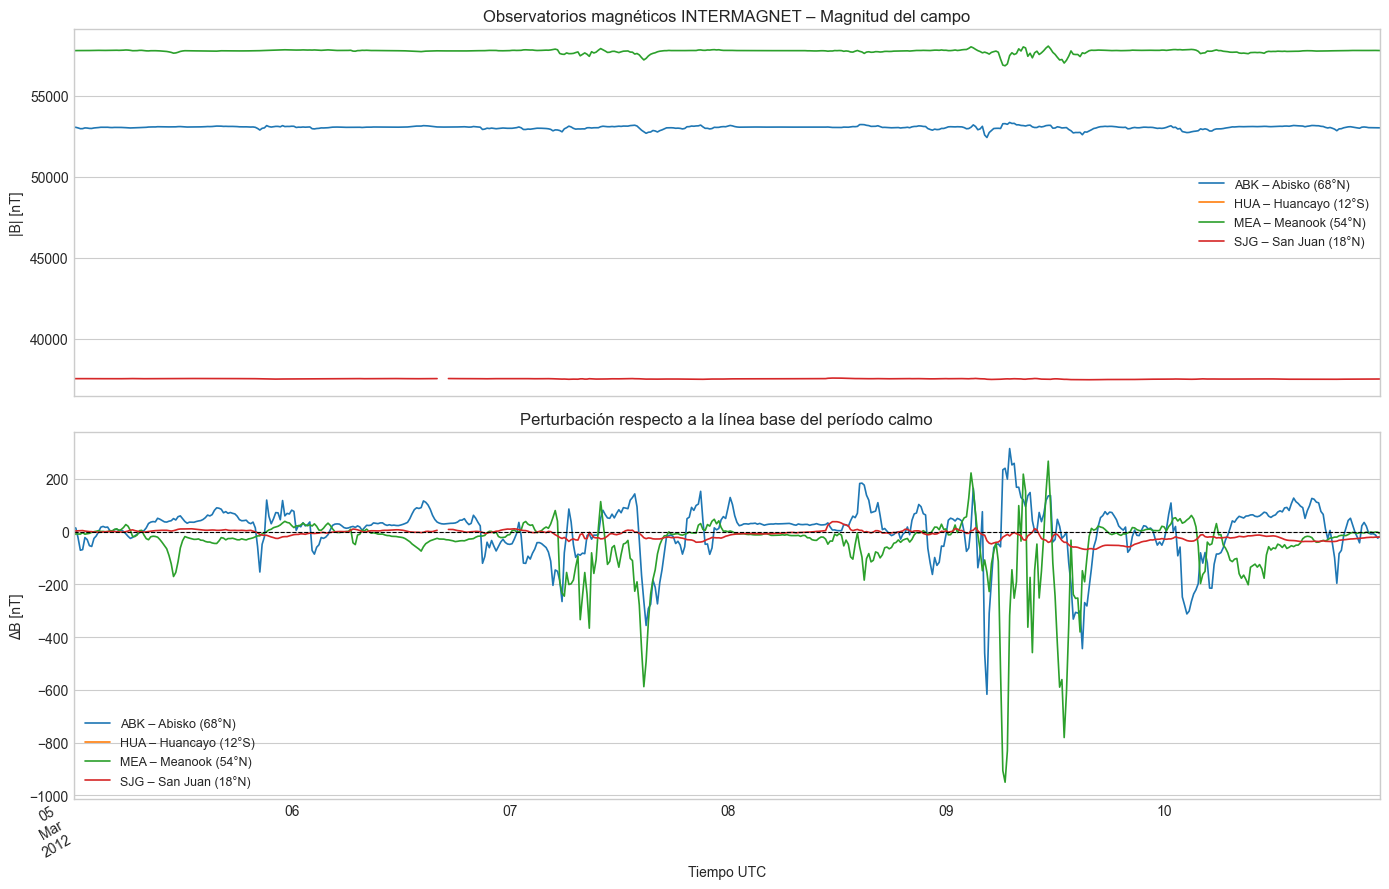

In [7]:
magnetometer_slugs = sorted(slug for slug in datasets if slug.startswith("intermagnet_"))
magnetometer_data = {}

station_labels = {
    "ABK": "ABK – Abisko (68°N)",
    "MEA": "MEA – Meanook (54°N)",
    "SJG": "SJG – San Juan (18°N)",
    "HUA": "HUA – Huancayo (12°S)",
}

for slug in magnetometer_slugs:
    station = slug.split("_")[1].upper()
    series = datasets[slug]["Field_Magnitude"].replace(99999.0, np.nan)
    magnetometer_data[station] = series

magnetic_field = pd.DataFrame(magnetometer_data).sort_index()
baseline_end = EVENT_START + pd.Timedelta(hours=6)
baseline = magnetic_field.loc[EVENT_START:baseline_end].median()
magnetic_delta = magnetic_field - baseline

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for col in magnetic_field.columns:
    label = station_labels.get(col, col)
    magnetic_field[col].resample("15min").mean().plot(ax=axes[0], linewidth=1.2, label=label)
axes[0].set_title("Observatorios magnéticos INTERMAGNET – Magnitud del campo")
axes[0].set_ylabel("|B| [nT]")
axes[0].legend(fontsize=9)

for col in magnetic_delta.columns:
    label = station_labels.get(col, col)
    magnetic_delta[col].resample("15min").mean().plot(ax=axes[1], linewidth=1.2, label=label)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Perturbación respecto a la línea base del período calmo")
axes[1].set_ylabel("ΔB [nT]")
axes[1].set_xlabel("Tiempo UTC")
axes[1].legend(fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Viento solar: plasma y campo magnético (dataset `swpc_rtsw_plasma_P1M` y `swpc_rtsw_mag_P1M`)

El dataset `swpc_rtsw_plasma_P1M` (ISWA/SWPC) provee densidad de protones, velocidad de flujo y temperatura iónica a resolución de 1 minuto. El dataset `swpc_rtsw_mag_P1M` provee las componentes GSM del campo magnético interplanetario.

Los **valores de relleno** (fill values) típicos del producto son 9999 para campos y velocidades y 9.9e7 para temperatura; se reemplazan por `NaN` antes de graficar para no distorsionar las escalas.

Los **outliers** identificados ( alrededor de las 01:00 del 7 de marzo en densidad de protones y velocidades, y alrededor de las 20:00 del 8 de marzo en presión) corresponden a valores de  (999.99 y 99.99) 

/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/881600925.py:29: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Volumes/T7/tarea3-astroparticulas/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


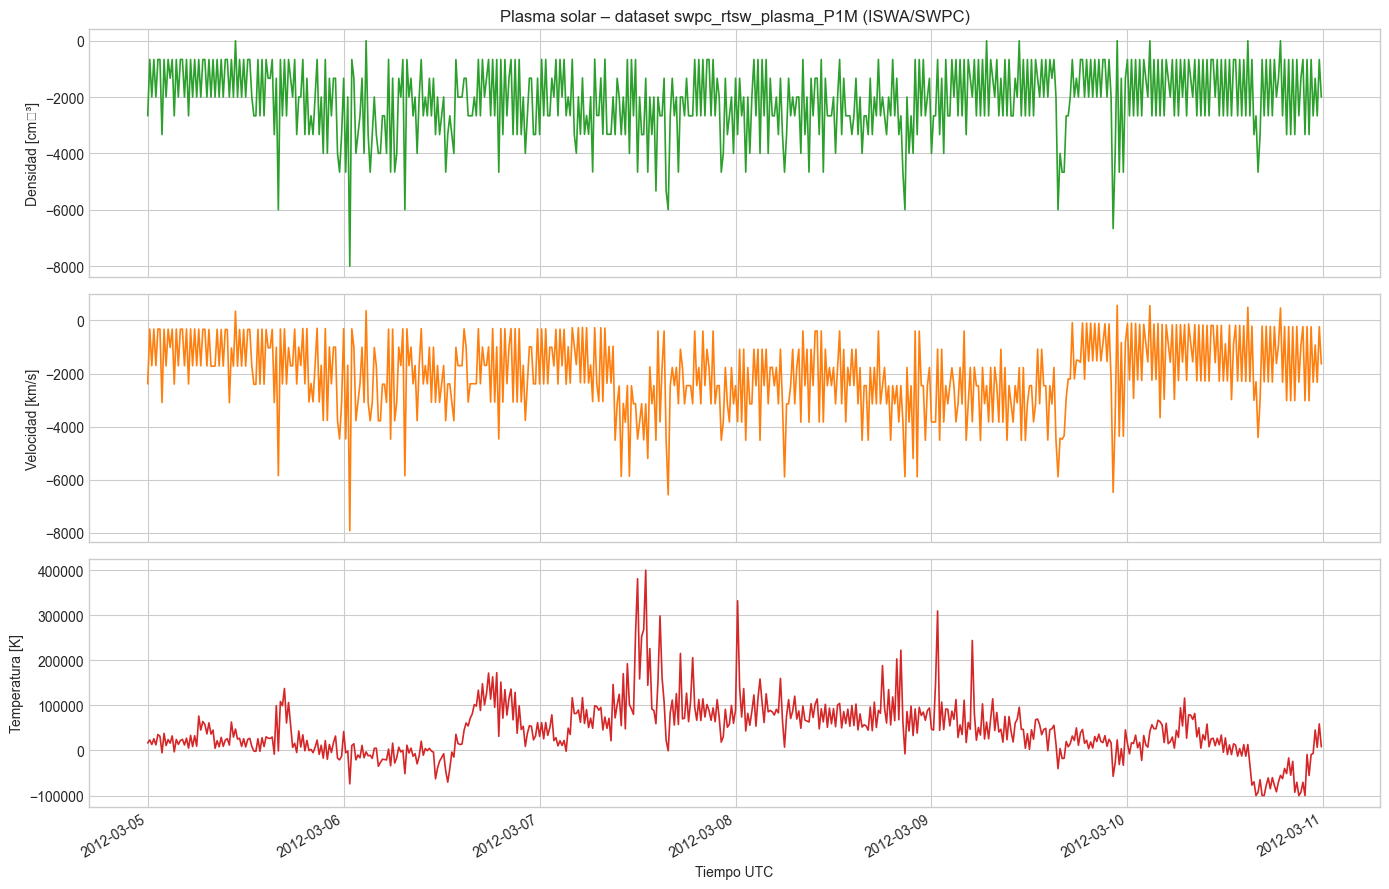

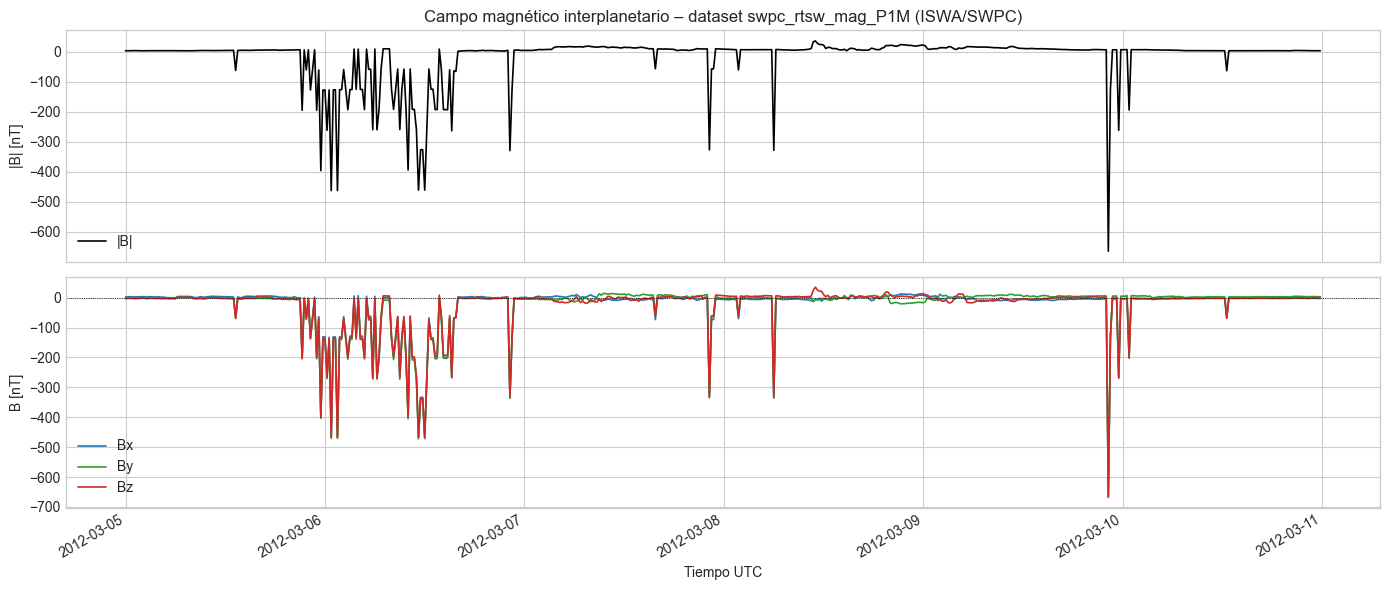

In [8]:
# ── Plasma SWPC (swpc_rtsw_plasma_P1M) ──────────────────────────────────────
FILL_PLASMA  = 9999.0   # valor de relleno del producto SWPC
FILL_TEMP    = 9.9e7

if "swpc_rtsw_plasma" in datasets:
    pl = datasets["swpc_rtsw_plasma"].copy()
    for col in ["ProtonDensity", "BulkSpeed"]:
        if col in pl.columns:
            pl[col] = pl[col].where(pl[col] < FILL_PLASMA)
    if "IonTemperature" in pl.columns:
        pl["IonTemperature"] = pl["IonTemperature"].where(pl["IonTemperature"] < FILL_TEMP)
    pl_15 = pl.resample("15min").mean()

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(pl_15.index, pl_15["ProtonDensity"], color="tab:green", linewidth=1.2)
    axes[0].set_ylabel("Densidad [cm⁻³]")
    axes[0].set_title("Plasma solar – dataset swpc_rtsw_plasma_P1M (ISWA/SWPC)")

    if "BulkSpeed" in pl_15.columns:
        axes[1].plot(pl_15.index, pl_15["BulkSpeed"], color="tab:orange", linewidth=1.2)
        axes[1].set_ylabel("Velocidad [km/s]")

    if "IonTemperature" in pl_15.columns:
        axes[2].plot(pl_15.index, pl_15["IonTemperature"], color="tab:red", linewidth=1.2)
        axes[2].set_ylabel("Temperatura [K]")

    axes[-1].set_xlabel("Tiempo UTC")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

# ── Campo magnético SWPC (swpc_rtsw_mag_P1M) ────────────────────────────────
FILL_MAG = 9999.0

if "swpc_rtsw_mag" in datasets:
    mg = datasets["swpc_rtsw_mag"].copy()
    for col in mg.columns:
        mg[col] = mg[col].where(mg[col].abs() < FILL_MAG)
    mg_15 = mg.resample("15min").mean()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(mg_15.index, mg_15["B_t"], color="black", linewidth=1.2, label="|B|")
    axes[0].set_ylabel("|B| [nT]")
    axes[0].set_title("Campo magnético interplanetario – dataset swpc_rtsw_mag_P1M (ISWA/SWPC)")
    axes[0].legend()

    for col, color, label in [("B_x", "tab:blue", "Bx"), ("B_y", "tab:green", "By"), ("B_z", "tab:red", "Bz")]:
        if col in mg_15.columns:
            axes[1].plot(mg_15.index, mg_15[col], color=color, linewidth=1.2, label=label)
    axes[1].axhline(0, color="black", linewidth=0.6, linestyle=":")
    axes[1].set_ylabel("B [nT]")
    axes[1].set_xlabel("Tiempo UTC")
    axes[1].legend()

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## Viento solar de alta resolución: OMNI HRO2 5 min (dataset `OMNI_HRO2_5MIN`)

El dataset `OMNI_HRO2_5MIN` de CDAWeb integra datos de viento solar de múltiples naves (ACE, Wind, Geotail) propagados a la órbita terrestre. Incluye campo magnético, velocidad del flujo (Vx, Vy, Vz), densidad, temperatura y presión dinámica a resolución de 5 minutos.

Los valores de relleno son: densidad = 999.99 cm⁻³, componentes de velocidad = 99999.9 km/s, presión = 99.99 nPa. Estos valores se reemplazan por `NaN` antes de graficar.

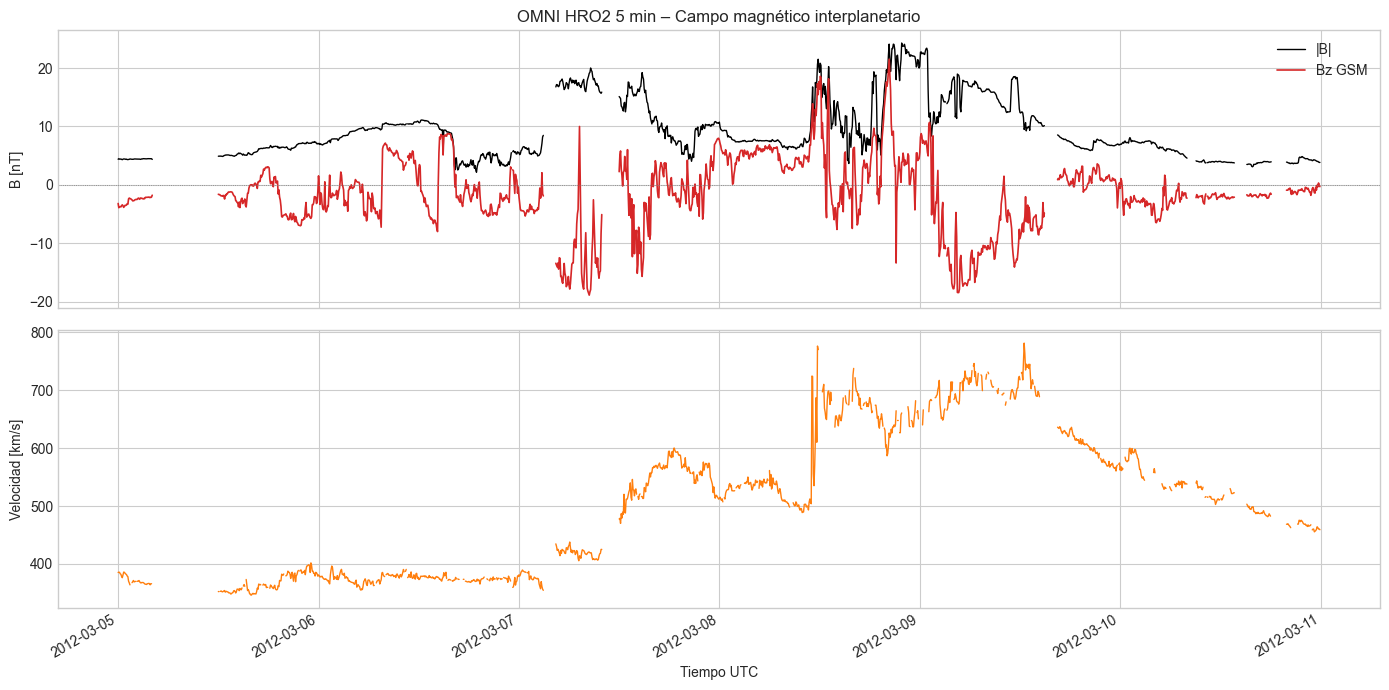

/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/4141182240.py:65: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


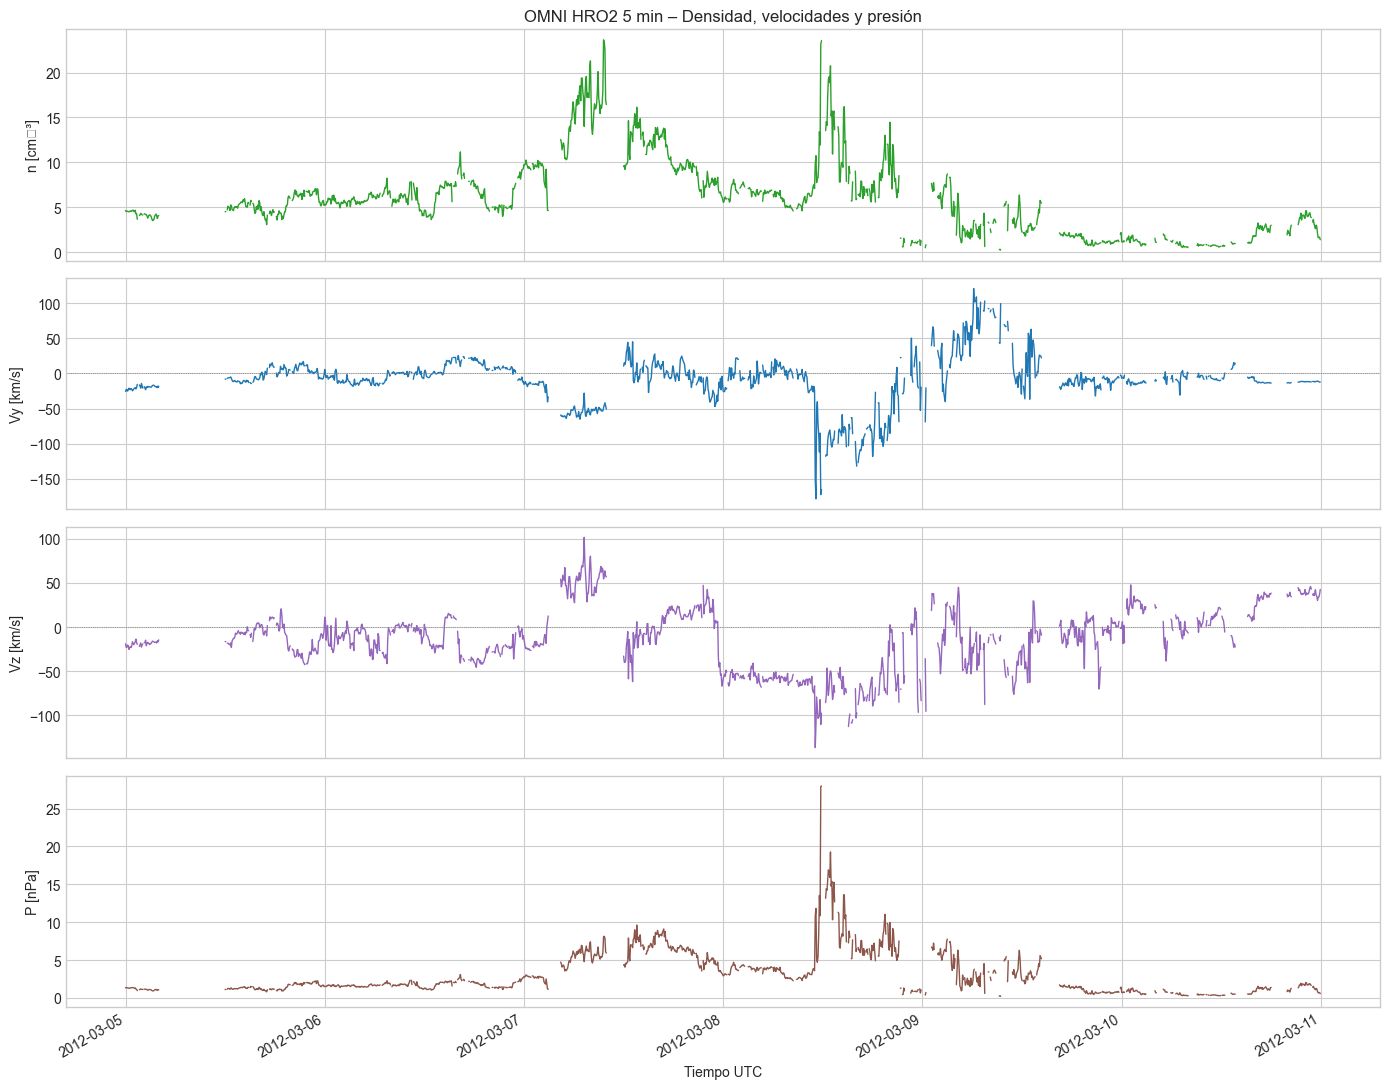

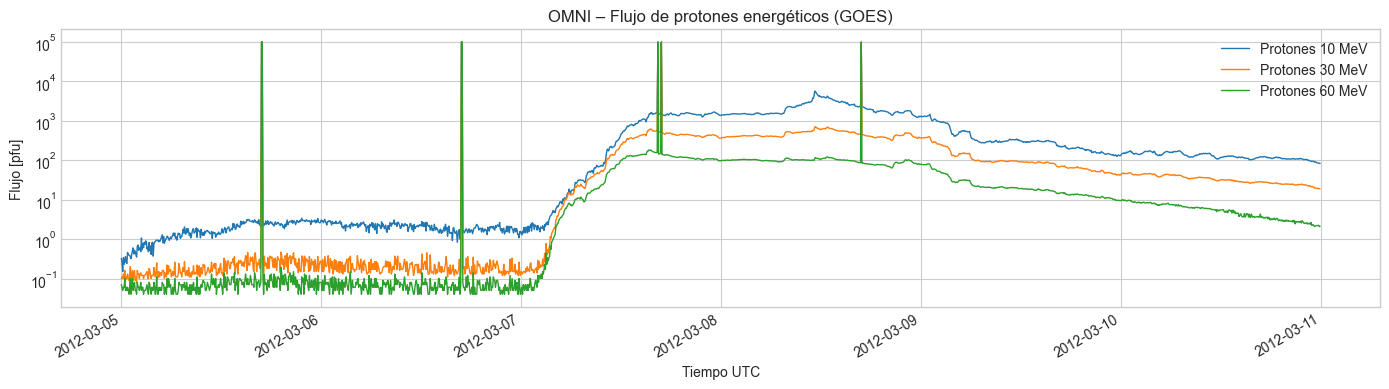

In [9]:
# ── OMNI HRO2 5 min (OMNI_HRO2_5MIN) ────────────────────────────────────────
FILL_DENSITY  = 999.99
FILL_VELOCITY = 99999.9
FILL_PRESSURE = 99.99
FILL_FIELD    = 9999.99
FILL_TEMP_OMNI = 9999999.0

if "omni_hro2_5min" in datasets:
    om = datasets["omni_hro2_5min"].copy()

    # Remover valores de relleno
    for col in ["proton_density"]:
        if col in om.columns:
            om[col] = om[col].where(om[col] < FILL_DENSITY)
    for col in ["flow_speed", "Vx", "Vy", "Vz"]:
        if col in om.columns:
            om[col] = om[col].where(om[col].abs() < FILL_VELOCITY)
    for col in ["Pressure"]:
        if col in om.columns:
            om[col] = om[col].where(om[col] < FILL_PRESSURE)
    for col in ["F", "BZ_GSM"]:
        if col in om.columns:
            om[col] = om[col].where(om[col].abs() < FILL_FIELD)
    if "T" in om.columns:
        om["T"] = om["T"].where(om["T"] < FILL_TEMP_OMNI)

    # Gráfico 1: Campo magnético y Bz
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    if "F" in om.columns:
        axes[0].plot(om.index, om["F"], color="black", linewidth=1, label="|B|")
    if "BZ_GSM" in om.columns:
        axes[0].plot(om.index, om["BZ_GSM"], color="tab:red", linewidth=1.2, label="Bz GSM")
        axes[0].axhline(0, color="gray", linewidth=0.6, linestyle=":")
    axes[0].set_ylabel("B [nT]")
    axes[0].set_title("OMNI HRO2 5 min – Campo magnético interplanetario")
    axes[0].legend()

    if "flow_speed" in om.columns:
        axes[1].plot(om.index, om["flow_speed"], color="tab:orange", linewidth=1)
    axes[1].set_ylabel("Velocidad [km/s]")
    axes[1].set_xlabel("Tiempo UTC")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # Gráfico 2: Densidad, Vy, Vz, Presión
    fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
    if "proton_density" in om.columns:
        axes[0].plot(om.index, om["proton_density"], color="tab:green", linewidth=1)
        axes[0].set_ylabel("n [cm⁻³]")
        axes[0].set_title("OMNI HRO2 5 min – Densidad, velocidades y presión")
    if "Vy" in om.columns:
        axes[1].plot(om.index, om["Vy"], color="tab:blue", linewidth=1)
        axes[1].axhline(0, color="gray", linewidth=0.6, linestyle=":")
        axes[1].set_ylabel("Vy [km/s]")
    if "Vz" in om.columns:
        axes[2].plot(om.index, om["Vz"], color="tab:purple", linewidth=1)
        axes[2].axhline(0, color="gray", linewidth=0.6, linestyle=":")
        axes[2].set_ylabel("Vz [km/s]")
    if "Pressure" in om.columns:
        axes[3].plot(om.index, om["Pressure"], color="tab:brown", linewidth=1)
        axes[3].set_ylabel("P [nPa]")
    axes[-1].set_xlabel("Tiempo UTC")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # Gráfico 3: Flujos de protones energéticos (contexto radiación)
    flux_cols = [c for c in ["PR-FLX_10", "PR-FLX_30", "PR-FLX_60"] if c in om.columns]
    if flux_cols:
        fig, ax = plt.subplots(figsize=(14, 4))
        for col in flux_cols:
            energy = col.replace("PR-FLX_", "") + " MeV"
            series = om[col].where(om[col] > 0)
            ax.semilogy(om.index, series, linewidth=1, label=f"Protones {energy}")
        ax.set_ylabel("Flujo [pfu]")
        ax.set_xlabel("Tiempo UTC")
        ax.set_title("OMNI – Flujo de protones energéticos (GOES)")
        ax.legend()
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()
else:
    print("OMNI HRO2 5 min no disponible localmente.")

## Partículas energéticas: dataset `AC_K0_EPM`

El dataset `AC_K0_EPM` de CDAWeb corresponde al instrumento EPAM (*Electron Proton Alpha Monitor*) a bordo de la nave ACE. Sin embargo, **este producto solo está disponible desde julio de 2017**, por lo que no cubre el evento de marzo de 2012.

Para el período de este análisis, los flujos de protones energéticos a 10, 30 y 60 MeV están disponibles en el dataset `OMNI_HRO2_5MIN` (campos `PR-FLX_10`, `PR-FLX_30`, `PR-FLX_60`), derivados de instrumentos GOES, y se graficaron en la sección anterior.

Esto ilustra una limitación real de los repositorios HAPI: la cobertura temporal de cada dataset varía según el instrumento y la misión. La interfaz HAPI reporta claramente la fecha de inicio del producto (`startDate`), permitiendo verificar la disponibilidad antes de solicitar datos.

## Imagenes LASCO C3

El archivo de URLs de LASCO no se grafica como serie fisica, pero sirve para documentar el contexto solar y construir una lista reproducible de imagenes asociadas al evento.


In [10]:
lasco = datasets.get("lasco_c3_urls")
if lasco is not None:
    cadence_minutes = lasco.index.to_series().diff().dropna().dt.total_seconds().div(60)
    print(f"Numero de imagenes listadas: {len(lasco)}")
    if not cadence_minutes.empty:
        print(f"Cadencia mediana: {cadence_minutes.median():.1f} minutos")
    display(lasco.head(10))
else:
    print("No existe un archivo LASCO local para este evento.")


Numero de imagenes listadas: 314
Cadencia mediana: 12.0 minutos


,url
Time,
2012-03-05 00:06:06+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:18:06+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:30:07+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:42:05+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:54:06+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 01:30:25+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 01:42:07+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 01:54:05+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 02:06:07+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...


# Resultados de Modelos CCMC

## Modelo Tsyganenko TS05 – Inner Magnetosphere (Run `Bryan_Yamashiro_061416_IM_3`)

El modelo **Tsyganenko TS05** es un modelo empírico del campo magnético de la magnetosfera terrestre. A diferencia de los modelos de viento solar (ENLIL, CORHEL), TS05 describe la estructura interna de la magnetosfera en función de condiciones del viento solar y el nivel de actividad geomagnética.

Los datos descargados del CCMC corresponden a líneas de campo magnético trazadas desde las naves **GOES-13**, **GOES-15** y **SDO** el **9 de marzo de 2012** (fase principal de la tormenta), cubriendo desde las 00:00 hasta las 09:24 UTC.

**Parámetros del modelo (PARMOD):**

| Índice | Parámetro | Unidad |
|--------|-----------|--------|
| 1 | Presión dinámica del viento solar (Pdyn) | nPa |
| 2 | Índice Dst | nT |
| 3–4 | Byimf, Bzimf | nT |
| 5–10 | Coeficientes G/W de corriente de tormenta | — |

La evolución temporal de Pdyn y Dst en PARMOD refleja las condiciones que el modelo usó para calcular la estructura del campo: comparar estos valores con las observaciones HAPI permite evaluar la consistencia entre los datos de entrada del modelo y las mediciones reales.

In [11]:
import zipfile, re
from pathlib import Path

CCMC_ZIP = Path("data/ccmc/2929_Bryan_Yamashiro_061416_IM_3_raw.zip")

def parse_tsyg_file(text):
    """Extrae metadata y datos de posición/campo de un archivo TSYG_INPUT."""
    meta = {}
    data_lines = []
    for line in text.split("\n"):
        if line.startswith("#"):
            if "Date, time:" in line:
                dt_str = line.split(":", 1)[1].strip()
                meta["datetime"] = pd.Timestamp(dt_str.replace("/", "-").replace("  ", "T").replace(" ", "T"), tz="UTC")
            elif "PARMOD:" in line:
                vals = list(map(float, line.split(":")[-1].split()))
                meta["Pdyn"] = vals[0]
                meta["Dst_model"] = vals[1]
                meta["Byimf"] = vals[2] if len(vals) > 2 else np.nan
                meta["Bzimf"] = vals[3] if len(vals) > 3 else np.nan
            elif "start position" in line:
                xyz = list(map(float, re.findall(r"[-+]?\d+\.\d+", line)))
                if len(xyz) >= 3:
                    meta["x0"], meta["y0"], meta["z0"] = xyz[:3]
        else:
            parts = line.split()
            if len(parts) == 6:
                try:
                    data_lines.append(list(map(float, parts)))
                except ValueError:
                    pass
    if data_lines:
        arr = np.array(data_lines)
        meta["X"] = arr[:, 0]
        meta["Y"] = arr[:, 1]
        meta["Z"] = arr[:, 2]
        meta["Bx"] = arr[:, 3]
        meta["By"] = arr[:, 4]
        meta["Bz"] = arr[:, 5]
    return meta


# ── Cargar metadata de todos los archivos ────────────────────────────────────
records = []
fieldlines = {}  # {(source, timestamp): metadata_with_field_line}

if CCMC_ZIP.exists():
    with zipfile.ZipFile(CCMC_ZIP) as z:
        data_names = sorted(
            n for n in z.namelist()
            if n.endswith(".txt") and not n.startswith("__MACOSX")
        )
        for name in data_names:
            fname = name.split("/")[-1]
            source = fname.split("_from_")[-1].split("_")[0]
            content = z.read(name).decode(errors="replace")
            m = parse_tsyg_file(content)
            if "datetime" in m:
                records.append({
                    "datetime": m["datetime"],
                    "source": source,
                    "Pdyn": m.get("Pdyn", np.nan),
                    "Dst_model": m.get("Dst_model", np.nan),
                    "Byimf": m.get("Byimf", np.nan),
                    "Bzimf": m.get("Bzimf", np.nan),
                    "x0": m.get("x0", np.nan),
                })
                fieldlines[(source, m["datetime"])] = m

    tsyg = pd.DataFrame(records).sort_values("datetime").reset_index(drop=True)
    print(f"Archivos cargados: {len(tsyg)}")
    print(f"Fuentes: {sorted(tsyg['source'].unique())}")
    print(f"Rango temporal: {tsyg['datetime'].min()} → {tsyg['datetime'].max()}")
    display(tsyg.groupby("source")[["Pdyn","Dst_model","Bzimf"]].describe().round(2))
else:
    tsyg = None
    print(f"Archivo no encontrado: {CCMC_ZIP}")

Archivos cargados: 424
Fuentes: ['goes13', 'goes15', 'sdo']
Rango temporal: 2012-03-09 00:00:00+00:00 → 2012-03-09 09:24:00+00:00


Pdyn                                           Dst_model         ...  \
        count  mean   std   min   25%   50%   75%   max     count   mean  ...   
source                                                                    ...   
goes13  142.0  3.84  2.41  0.55  1.97  3.33  5.83  8.73     142.0 -17.37  ...   
goes15  141.0  3.84  2.41  0.55  1.96  3.31  5.92  8.73     141.0 -17.22  ...   
sdo     141.0  3.84  2.41  0.55  1.96  3.31  5.92  8.73     141.0 -17.22  ...   

                   Bzimf                                     
         75%  max  count mean  std  min  25%  50%  75%  max  
source                                                       
goes13 -11.0 -4.0  142.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
goes15 -11.0 -4.0  141.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
sdo    -11.0 -4.0  141.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[3 rows x 24 columns]

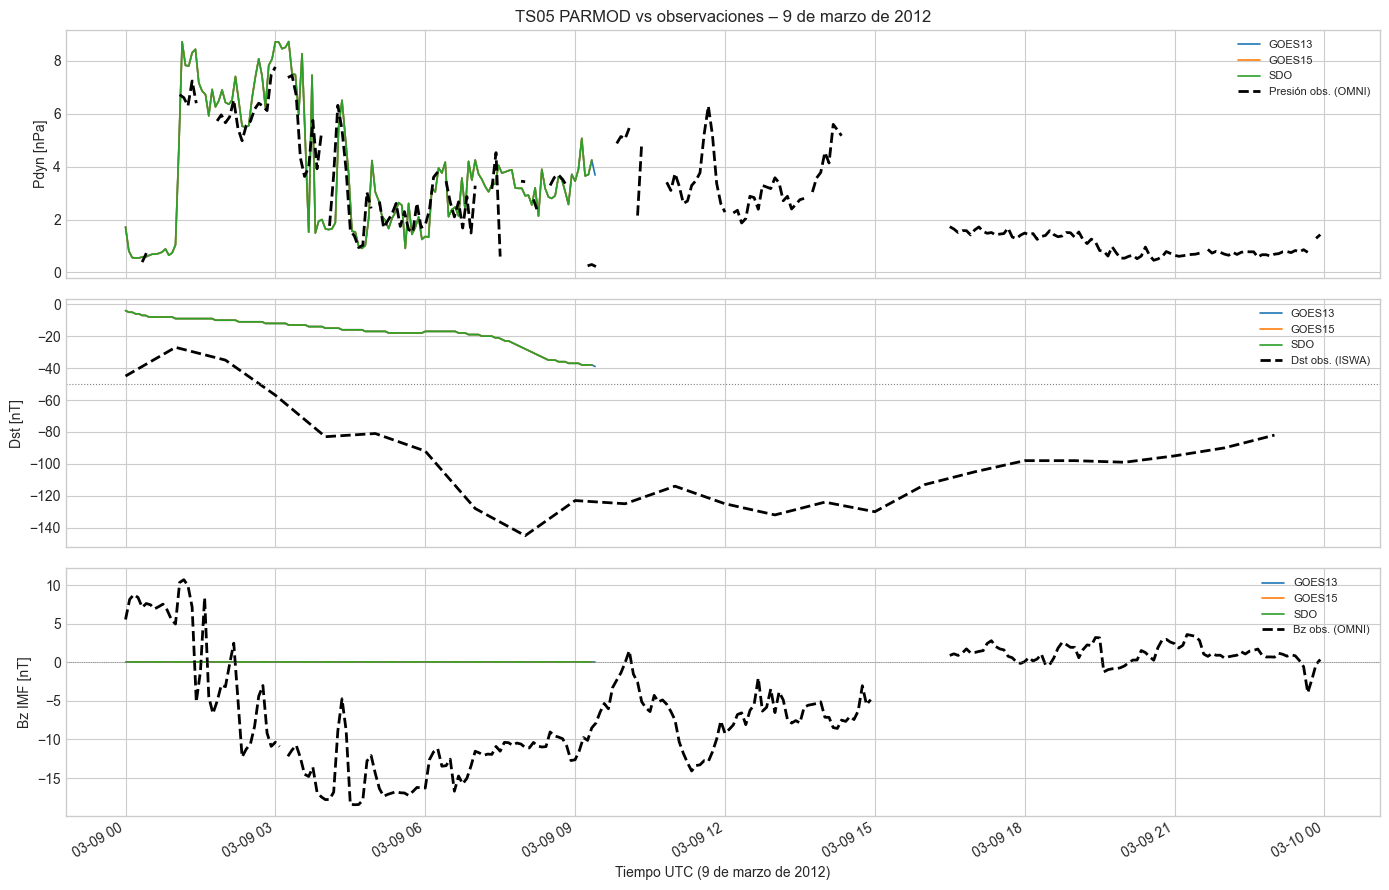

In [12]:
if tsyg is not None:
    # ── Gráfico 1: parámetros PARMOD vs tiempo (comparación con observaciones)
    colors = {"goes13": "tab:blue", "goes15": "tab:orange", "sdo": "tab:green"}

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    for src, grp in tsyg.groupby("source"):
        grp = grp.set_index("datetime").sort_index()
        axes[0].plot(grp.index, grp["Pdyn"],      color=colors[src], linewidth=1.2, label=src.upper())
        axes[1].plot(grp.index, grp["Dst_model"], color=colors[src], linewidth=1.2, label=src.upper())
        axes[2].plot(grp.index, grp["Bzimf"],     color=colors[src], linewidth=1.2, label=src.upper())

    # Superponer Dst observado del 9 de marzo para comparación
    if dst is not None:
        dst_march9 = dst.loc["2012-03-09"]
        axes[1].plot(dst_march9.index, dst_march9["Dst"],
                     color="black", linewidth=2, linestyle="--", label="Dst obs. (ISWA)")
    if "omni_hro2_5min" in datasets:
        om_march9 = datasets["omni_hro2_5min"].loc["2012-03-09"].copy()
        om_march9["Pressure"] = om_march9["Pressure"].where(om_march9["Pressure"] < FILL_PRESSURE)
        axes[0].plot(om_march9.index, om_march9["Pressure"],
                     color="black", linewidth=2, linestyle="--", label="Presión obs. (OMNI)")
        om_bz = om_march9["BZ_GSM"].where(om_march9["BZ_GSM"].abs() < FILL_FIELD)
        axes[2].plot(om_march9.index, om_bz,
                     color="black", linewidth=2, linestyle="--", label="Bz obs. (OMNI)")

    axes[0].set_ylabel("Pdyn [nPa]")
    axes[0].set_title("TS05 PARMOD vs observaciones – 9 de marzo de 2012")
    axes[0].legend(fontsize=8)
    axes[1].axhline(DST_STORM_THRESHOLD, color="gray", linewidth=0.8, linestyle=":")
    axes[1].set_ylabel("Dst [nT]")
    axes[1].legend(fontsize=8)
    axes[2].axhline(0, color="gray", linewidth=0.6, linestyle=":")
    axes[2].set_ylabel("Bz IMF [nT]")
    axes[2].set_xlabel("Tiempo UTC (9 de marzo de 2012)")
    axes[2].legend(fontsize=8)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

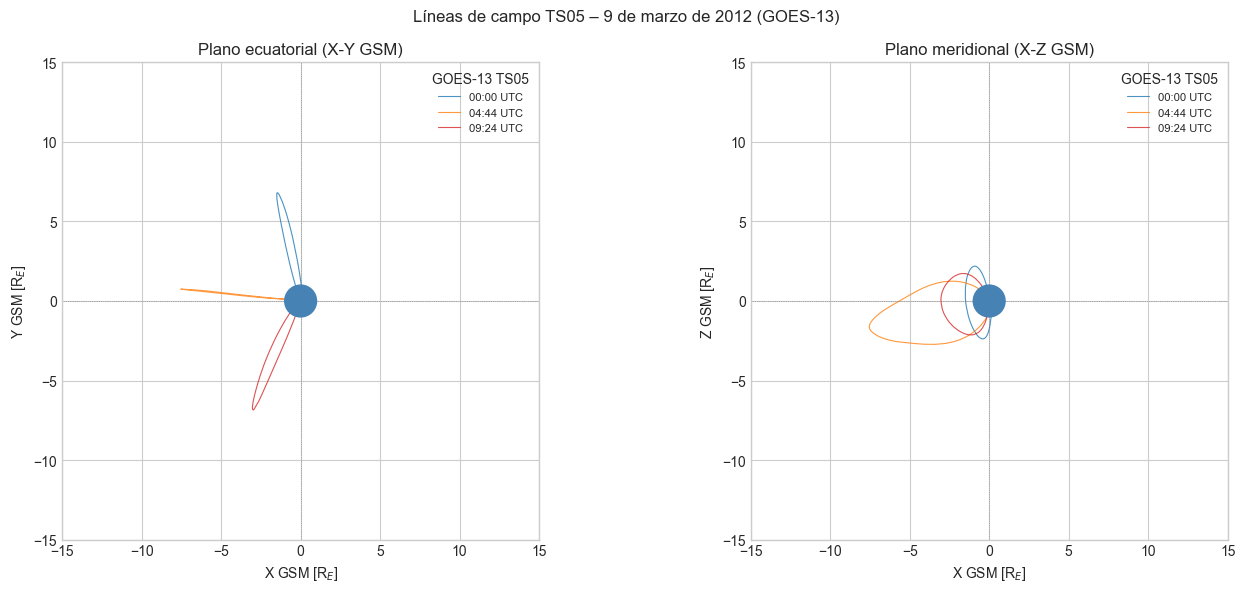

In [13]:
if tsyg is not None and fieldlines:
    # ── Gráfico 2: líneas de campo en el plano ecuatorial (X-Y GSM)
    # Seleccionar 3 instantes: inicio, intermedio y final del período disponible
    source_plot = "goes13"
    times_src = sorted(t for (s, t) in fieldlines if s == source_plot)
    n = len(times_src)
    selected = [times_src[0], times_src[n // 2], times_src[-1]]
    step_colors = ["tab:blue", "tab:orange", "tab:red"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for t, color in zip(selected, step_colors):
        fl = fieldlines.get((source_plot, t), {})
        if "X" not in fl:
            continue
        label = t.strftime("%H:%M UTC")
        # Plano X-Y (ecuatorial)
        axes[0].plot(fl["X"], fl["Y"], color=color, linewidth=0.8, alpha=0.8, label=label)
        # Plano X-Z (meridional)
        axes[1].plot(fl["X"], fl["Z"], color=color, linewidth=0.8, alpha=0.8, label=label)

    # Dibujar la Tierra
    for ax in axes:
        circle = plt.Circle((0, 0), 1, color="steelblue", zorder=5)
        ax.add_patch(circle)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
        ax.axvline(0, color="gray", linewidth=0.5, linestyle=":")
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.legend(fontsize=8, title=f"GOES-13 TS05")
        ax.set_xlabel("X GSM [R$_E$]")

    axes[0].set_ylabel("Y GSM [R$_E$]")
    axes[0].set_title("Plano ecuatorial (X-Y GSM)")
    axes[1].set_ylabel("Z GSM [R$_E$]")
    axes[1].set_title("Plano meridional (X-Z GSM)")

    fig.suptitle("Líneas de campo TS05 – 9 de marzo de 2012 (GOES-13)", fontsize=12)
    plt.tight_layout()
    plt.show()

## Modelo CORHEL-SH: Viento Solar de Fondo – Run `StephanieCarolina_CelyRodriguez_030726_SH_1`

El modelo **CORHEL-SH** (*CORona-HELiosphere Solar Heliosphere*) combina el modelo MAS (*Magnetohydrodynamics Around a Sphere*) de la corona interna con el modelo heliofísico del viento solar de fondo. A diferencia del modelo TS05 (que describe la magnetosfera terrestre en respuesta al viento solar), CORHEL-SH modela el **extremo solar** de la cadena Sol–Tierra: estructura de la corona, distribución del viento solar y campo magnético hasta la órbita terrestre.

El run `StephanieCarolina_CelyRodriguez_030726_SH_1` corresponde a la **rotación de Carrington CR 2121** (19 de febrero – 17 de marzo de 2012), período que incluye la tormenta geomagnética del 7-10 de marzo. Los datos modelados describen el **viento solar de fondo** (sin CME), es decir, las condiciones ambientales a través de las cuales se propagó la CME del 5 de marzo.

Los resultados utilizados aquí son:

| Archivo | Descripción | Grid |
|---------|-------------|------|
| `corona_a/pfss/br_photo.hdf` | Campo radial fotosférico (magnetograma PFSS) | φ × θ: 182×76 |
| `corona_a/quantities_at_r1/solar_wind_mhd/vr_r1.hdf` | Velocidad radial del viento solar en r₁ = 21.5 R☉ | φ × θ: 182×84 |
| `corona_a/quantities_at_r1/solar_wind_mhd/rho_r1.hdf` | Densidad numérica en r₁ | φ × θ: 182×84 |
| `corona/br002_1.10.hdf` | Campo radial coronal en 1.10 R☉ | φ × θ: 181×83 |

Los archivos están en formato HDF4 (Scientific Data Set). Se implementa un lector mínimo en Python puro ya que la librería `pyhdf` no tiene distribución binaria para Python 3.14 / ARM64.

In [14]:
import struct, tarfile

CORHEL_TAR = CCMC_DIR / "2928_StephanieCarolina_CelyRodriguez_030726_SH_1_raw.tar"

# ── Lector mínimo de HDF4 SDS (Scientific Data Set) ─────────────────────────
# Tags relevantes: 701 = SDD (dimensiones), 702 = SD (datos), 703 = SDS (coordenadas)
def parse_hdf4_sds(raw: bytes):
    """
    Lee un archivo HDF4 SDS de salida del modelo MAS/CORHEL.
    Retorna (array_2d, [coord_dim0, coord_dim1]).
    Los datos se almacenan en big-endian float32.
    """
    assert raw[:4] == b'\x0e\x03\x13\x01', "No es un archivo HDF4 válido"
    # Bloque de descriptores comienza en offset 10 (4 magic + 6 cabecera de bloque)
    dds = {}
    for i in range(60):
        pos = 10 + i * 12
        if pos + 12 > len(raw):
            break
        tag, ref, offset, length = struct.unpack(">HHII", raw[pos:pos+12])
        if tag == 0 and ref == 0:
            continue
        dds.setdefault(tag, []).append((offset, length))

    # Tag 701: Scientific Data Dimensions (rank + shape + tipo de dato)
    sdd_off, sdd_len = dds[701][0]
    sdd = raw[sdd_off:sdd_off + sdd_len]
    rank = struct.unpack(">H", sdd[0:2])[0]
    dims = [struct.unpack(">I", sdd[2 + i*4:6 + i*4])[0] for i in range(rank)]

    # Tag 703: coordenadas de cada dimensión (escala de ejes)
    coords = []
    if 703 in dds:
        sds_off, sds_len = dds[703][0]
        sds = raw[sds_off:sds_off + sds_len]
        ptr = 0
        for d in dims:
            ptr += 1                                          # flag "has scale"
            c = np.frombuffer(sds[ptr:ptr + d*4], dtype='>f4').copy()
            coords.append(c)
            ptr += d * 4

    # Tag 702: datos (float32 big-endian)
    sd_off, sd_len = dds[702][0]
    arr = np.frombuffer(raw[sd_off:sd_off + sd_len], dtype='>f4').reshape(dims)
    return arr, coords


def read_corhel(internal_path: str):
    """Extrae y parsea un archivo HDF4 del tar CORHEL sin descomprimirlo a disco."""
    with tarfile.open(CORHEL_TAR) as tf:
        raw = tf.extractfile(internal_path).read()
    return parse_hdf4_sds(raw)


# ── Cargar campos clave ───────────────────────────────────────────────────────
print("Cargando campos CORHEL desde el tar…")
vr_r1,  (phi_vr,  theta_vr)  = read_corhel("./corona_a/quantities_at_r1/solar_wind_mhd/vr_r1.hdf")
rho_r1, (phi_rho, theta_rho) = read_corhel("./corona_a/quantities_at_r1/solar_wind_mhd/rho_r1.hdf")
br_photo, (phi_ph, theta_ph) = read_corhel("./corona_a/pfss/br_photo.hdf")
br_cor110, (phi_c, theta_c)  = read_corhel("./corona/br002_1.10.hdf")
print("  OK")

# ── Grillas de coordenadas ────────────────────────────────────────────────────
# phi (longitud de Carrington) – el array almacenado tiene corrupción numérica;
# se reconstruye la grilla uniforme 0–360°.
def make_phi_deg(n): return np.linspace(0, 360, n, endpoint=False)

# theta (colatitud) → latitud geográfica
def theta_to_lat(theta): return 90.0 - np.degrees(theta)

phi_vr_deg   = make_phi_deg(vr_r1.shape[0])
lat_vr       = theta_to_lat(theta_vr)

phi_ph_deg   = make_phi_deg(br_photo.shape[0])
lat_ph       = theta_to_lat(theta_ph)

phi_c_deg    = make_phi_deg(br_cor110.shape[0])
lat_c        = theta_to_lat(theta_c)

# ── Longitud de Carrington de la Tierra durante el evento ────────────────────
# CR 2121 inició ≈ 2012-02-19T05:55 UT.  La Tierra recorre ≈13.2°/día en el
# marco de Carrington.  Al 7 de marzo (16.75 días después) la longitud es:
CR2121_START   = pd.Timestamp("2012-02-19T05:55:00Z")
CAR_ROT_DAYS   = 27.2753
EARTH_CAR_RATE = 360.0 / CAR_ROT_DAYS          # grados por día

earth_lon_march7  = (360 - (EVENT_START + pd.Timedelta(days=2) - CR2121_START).days  * EARTH_CAR_RATE) % 360
earth_lon_march10 = (360 - (EVENT_STOP  - CR2121_START).days * EARTH_CAR_RATE) % 360
print(f"Longitud de Carrington de la Tierra (7 mar): {earth_lon_march7:.1f}°")
print(f"Longitud de Carrington de la Tierra (10 mar): {earth_lon_march10:.1f}°")

# ── Normalización de unidades MAS ─────────────────────────────────────────────
# vr está normalizado por la velocidad de referencia del modelo MAS (481.37 km/s)
MAS_VR_REF = 481.37     # km/s
vr_kms = vr_r1 * MAS_VR_REF

summary_rows = [
    {"campo": "vr (r₁=21.5R☉)", "shape": str(vr_r1.shape), "mín": f"{float(vr_kms.min()):.0f} km/s", "máx": f"{float(vr_kms.max()):.0f} km/s"},
    {"campo": "ρ  (r₁=21.5R☉)", "shape": str(rho_r1.shape), "mín": f"{float(rho_r1.min()):.2e}", "máx": f"{float(rho_r1.max()):.2e}"},
    {"campo": "Br (fotosfera)",  "shape": str(br_photo.shape), "mín": f"{float(br_photo.min()):.2f} G", "máx": f"{float(br_photo.max()):.2f} G"},
    {"campo": "Br (1.10 R☉)",   "shape": str(br_cor110.shape), "mín": f"{float(br_cor110.min()):.3f}", "máx": f"{float(br_cor110.max()):.3f}"},
]
display(pd.DataFrame(summary_rows))

Cargando campos CORHEL desde el tar…
  OK
Longitud de Carrington de la Tierra (7 mar): 148.8°
Longitud de Carrington de la Tierra (10 mar): 96.0°


,campo,shape,mín,máx
0,vr (r₁=21.5R☉),"(182, 84)",307 km/s,741 km/s
1,ρ (r₁=21.5R☉),"(182, 84)",8.59e-07,6.75e-06
2,Br (fotosfera),"(182, 76)",-33.38 G,24.16 G
3,Br (1.10 R☉),"(181, 83)",-4.421,2.177


/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/288266464.py:55: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()
/Volumes/T7/tarea3-astroparticulas/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


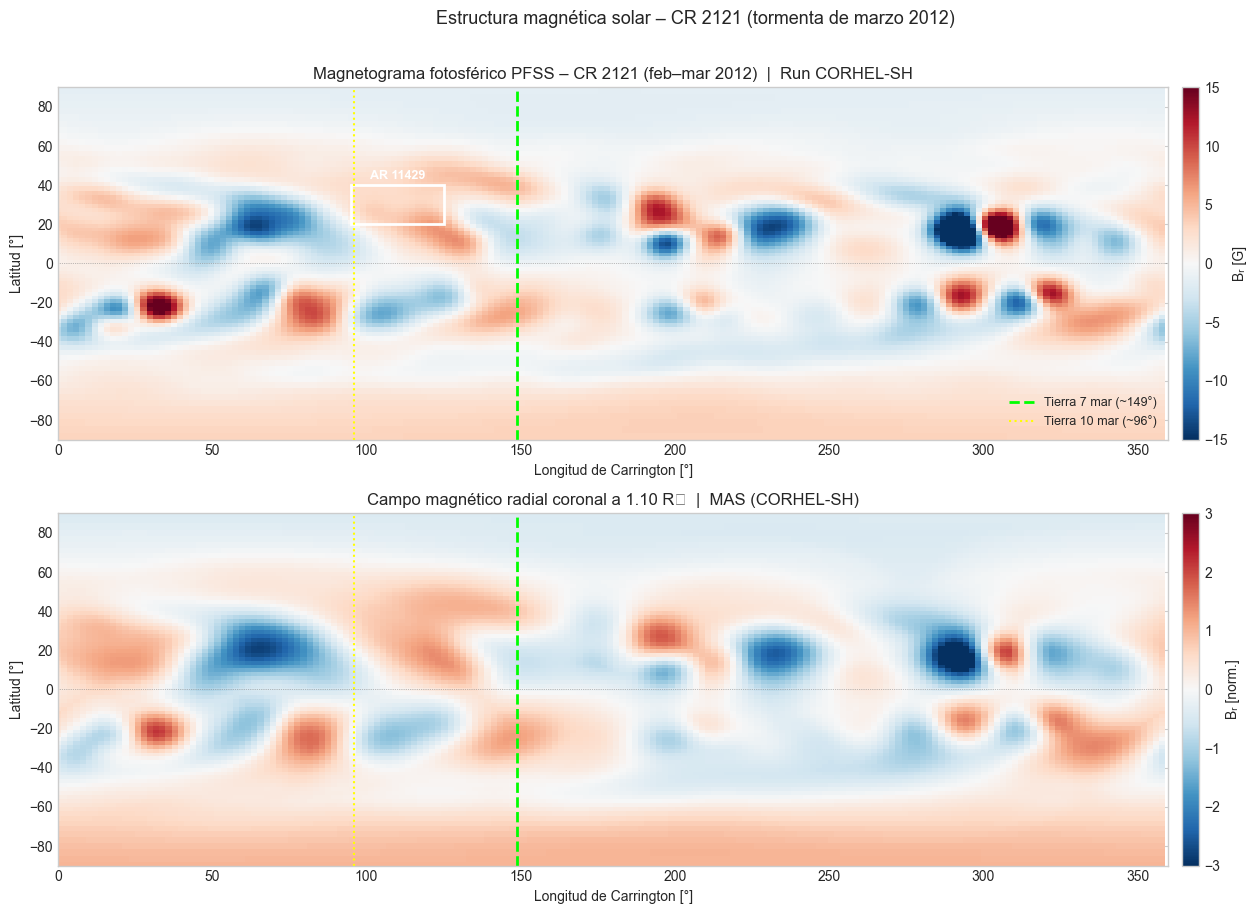

In [15]:
# ── Magnetograma fotosférico PFSS (CR 2121) ───────────────────────────────────
# br_photo.hdf contiene el campo radial en la fotosfera (1 R☉) en unidades de Gauss.
# Los valores positivos (rojo) indican flujo saliente; negativos (azul) entrante.
# La región activa AR 11429 (fuente de la CME del 5 de marzo) aparece como
# bipolo intenso alrededor de 30°N en la longitud de Carrington ≈ 90°–120°.

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Panel 1: Magnetograma fotosférico ──────────────────────────────────────────
ax = axes[0]
# br_photo: shape (phi, theta) -> transponer para que X=lon, Y=lat
Bsat = 15.0   # saturar en ±15 G para resaltar estructura de regiones activas
im = ax.pcolormesh(
    phi_ph_deg, lat_ph,
    np.clip(br_photo, -Bsat, Bsat).T,
    cmap="RdBu_r", vmin=-Bsat, vmax=Bsat,
    shading="auto",
)
cb = fig.colorbar(im, ax=ax, label="Bᵣ [G]", pad=0.01)
# Marcar posición de la Tierra durante el evento (7-10 mar → ~139°–100°)
ax.axvline(earth_lon_march7,  color="lime", linewidth=2, linestyle="--", label=f"Tierra 7 mar (~{earth_lon_march7:.0f}°)")
ax.axvline(earth_lon_march10, color="yellow", linewidth=1.5, linestyle=":",  label=f"Tierra 10 mar (~{earth_lon_march10:.0f}°)")
# Marcar región activa AR 11429 (longitud estimada ~100°–120°, latitud ~25°–35°N)
ax.add_patch(plt.Rectangle((95, 20), 30, 20,
             edgecolor="white", facecolor="none", linewidth=2, linestyle="-"))
ax.text(110, 43, "AR 11429", color="white", fontsize=9, ha="center", fontweight="bold")
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitud de Carrington [°]")
ax.set_ylabel("Latitud [°]")
ax.set_title("Magnetograma fotosférico PFSS – CR 2121 (feb–mar 2012)  |  Run CORHEL-SH")
ax.legend(fontsize=9, loc="lower right")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")

# ── Panel 2: Campo coronal a 1.10 R☉ (estructura de campo abierto/cerrado) ──
ax = axes[1]
Bcsat = 3.0
im2 = ax.pcolormesh(
    phi_c_deg, lat_c,
    np.clip(br_cor110, -Bcsat, Bcsat).T,
    cmap="RdBu_r", vmin=-Bcsat, vmax=Bcsat,
    shading="auto",
)
fig.colorbar(im2, ax=ax, label="Bᵣ [norm.]", pad=0.01)
ax.axvline(earth_lon_march7,  color="lime", linewidth=2, linestyle="--")
ax.axvline(earth_lon_march10, color="yellow", linewidth=1.5, linestyle=":")
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitud de Carrington [°]")
ax.set_ylabel("Latitud [°]")
ax.set_title("Campo magnético radial coronal a 1.10 R☉  |  MAS (CORHEL-SH)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")

fig.suptitle("Estructura magnética solar – CR 2121 (tormenta de marzo 2012)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/3078341932.py:54: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()


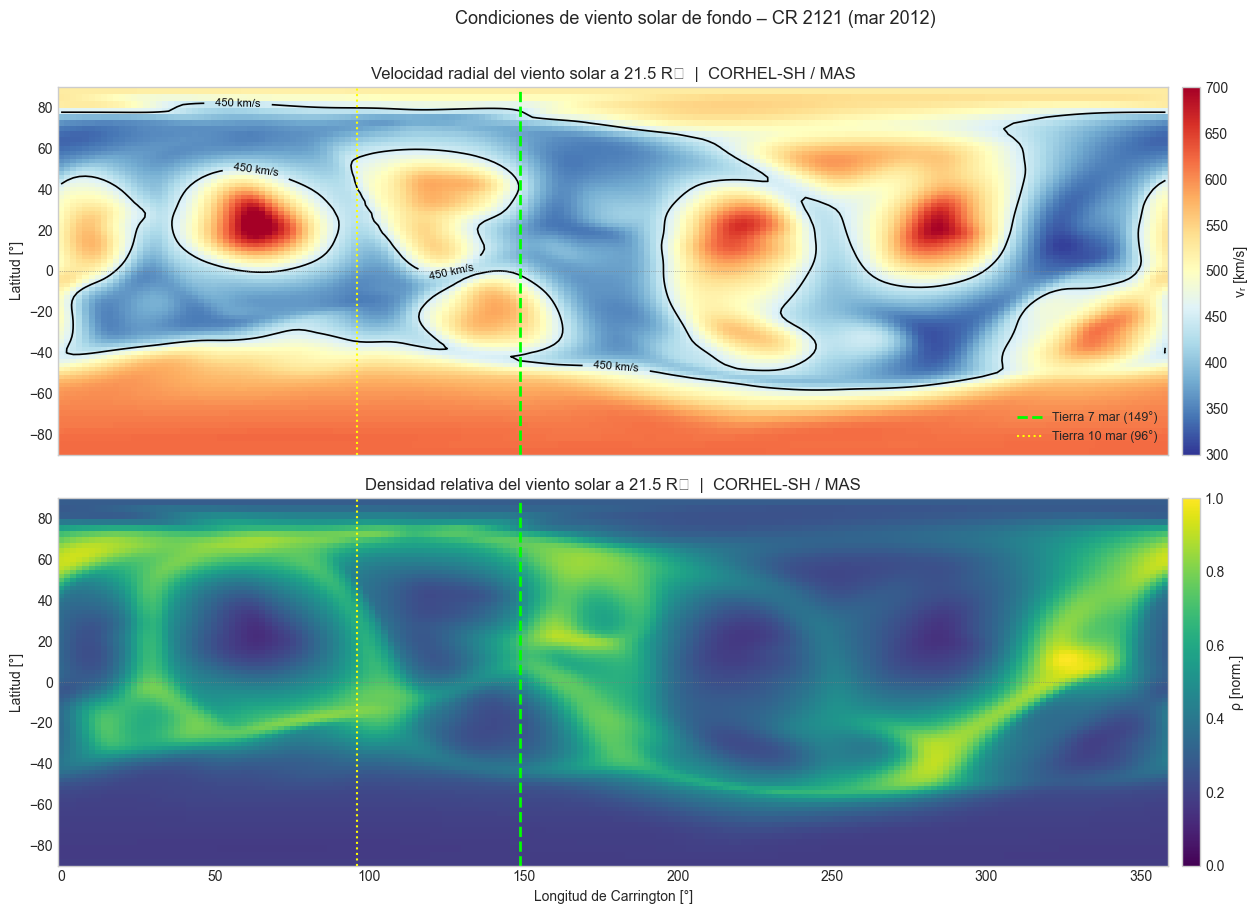

In [16]:
# ── Viento solar de fondo en r₁ = 21.5 R☉  ──────────────────────────────────
# vr_r1: velocidad radial (normalizada, ×481.37 km/s → km/s)
# rho_r1: densidad (unidades normalizadas MAS; se muestra el patrón relativo)
# La franja de viento lento (vr < 450 km/s) rodea el ecuador; las regiones
# de viento rápido (vr > 550 km/s) se asocian con huecos coronales.

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Panel 1: Velocidad radial (km/s) ─────────────────────────────────────────
ax = axes[0]
im = ax.pcolormesh(
    phi_vr_deg, lat_vr,
    vr_kms.T,
    cmap="RdYlBu_r", vmin=300, vmax=700,
    shading="auto",
)
fig.colorbar(im, ax=ax, label="vᵣ [km/s]", pad=0.01)
# Contorno de 450 km/s: frontera viento lento / viento rápido
try:
    ct = ax.contour(phi_vr_deg, lat_vr, vr_kms.T, levels=[450], colors="black", linewidths=1.2)
    ax.clabel(ct, fmt="450 km/s", fontsize=8)
except Exception:
    pass
ax.axvline(earth_lon_march7,  color="lime",   linewidth=2,   linestyle="--",
           label=f"Tierra 7 mar ({earth_lon_march7:.0f}°)")
ax.axvline(earth_lon_march10, color="yellow", linewidth=1.5, linestyle=":",
           label=f"Tierra 10 mar ({earth_lon_march10:.0f}°)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_ylim(-90, 90)
ax.set_ylabel("Latitud [°]")
ax.set_title("Velocidad radial del viento solar a 21.5 R☉  |  CORHEL-SH / MAS")
ax.legend(fontsize=9, loc="lower right")

# ── Panel 2: Densidad relativa ────────────────────────────────────────────────
ax = axes[1]
# Normalizar densidad al valor máximo para mostrar patrón relativo
rho_norm = rho_r1 / float(rho_r1.max())
im2 = ax.pcolormesh(
    phi_vr_deg, lat_vr,
    rho_norm.T,
    cmap="viridis", vmin=0, vmax=1,
    shading="auto",
)
fig.colorbar(im2, ax=ax, label="ρ [norm.]", pad=0.01)
ax.axvline(earth_lon_march7,  color="lime",   linewidth=2,   linestyle="--")
ax.axvline(earth_lon_march10, color="yellow", linewidth=1.5, linestyle=":")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitud de Carrington [°]")
ax.set_ylabel("Latitud [°]")
ax.set_title("Densidad relativa del viento solar a 21.5 R☉  |  CORHEL-SH / MAS")

fig.suptitle("Condiciones de viento solar de fondo – CR 2121 (mar 2012)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Velocidad OMNI período calmo (5-6 mar): 372 ± 11 km/s


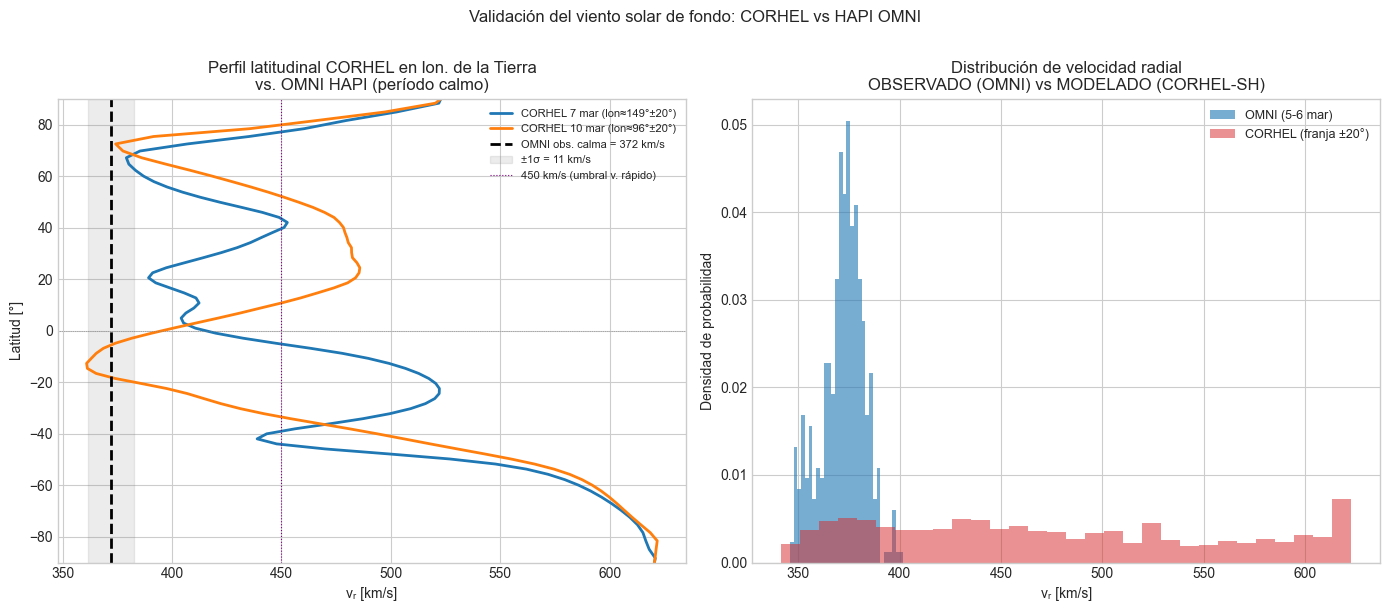


Resumen comparativo:
  CORHEL vr en lon. Tierra (7  mar, lat=0°): 443 km/s
  CORHEL vr en lon. Tierra (10 mar, lat=0°): 367 km/s
  OMNI observado (5-6 mar, período calmo):   372 ± 11 km/s


In [17]:
# ── Comparación: CORHEL vr en la longitud de la Tierra vs HAPI OMNI ──────────
# Se extrae la velocidad radial modelada en la longitud de Carrington de la
# Tierra (±20°) y se compara con el viento solar observado por OMNI HRO2 5 min
# durante los días calmos (5-6 de marzo, línea base de la tormenta).

# ── 1. Perfil latitudinal de vr en la longitud de la Tierra ──────────────────
delta_lon = 20.0   # ± grados alrededor de la longitud de la Tierra

def lon_mask(phi_arr, center, delta):
    """Máscara booleana para longitudes dentro de [center-delta, center+delta] (mod 360)."""
    d = np.abs((phi_arr - center + 180) % 360 - 180)
    return d <= delta

mask7  = lon_mask(phi_vr_deg, earth_lon_march7,  delta_lon)
mask10 = lon_mask(phi_vr_deg, earth_lon_march10, delta_lon)

# Perfil latitudinal: media sobre la franja de longitud
vr_lat_7  = vr_kms[mask7,  :].mean(axis=0)   # media sobre phi → función de lat
vr_lat_10 = vr_kms[mask10, :].mean(axis=0)

# ── 2. Velocidad observada HAPI OMNI durante el período calmo ─────────────────
quiet_start = EVENT_START
quiet_end   = EVENT_START + pd.Timedelta(days=2)   # 5-6 de marzo

vr_obs_quiet = None
if "omni_hro2_5min" in datasets:
    om_quiet = datasets["omni_hro2_5min"].loc[quiet_start:quiet_end, "flow_speed"].copy()
    om_quiet = om_quiet.where(om_quiet < FILL_VELOCITY)
    vr_obs_mean = float(om_quiet.mean())
    vr_obs_std  = float(om_quiet.std())
    vr_obs_quiet = (vr_obs_mean, vr_obs_std)
    print(f"Velocidad OMNI período calmo (5-6 mar): {vr_obs_mean:.0f} ± {vr_obs_std:.0f} km/s")

# ── 3. Gráfico comparativo ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: perfil latitudinal CORHEL a Earth longitude
ax = axes[0]
ax.plot(vr_lat_7,  lat_vr, color="tab:blue",   linewidth=2, label=f"CORHEL 7 mar (lon≈{earth_lon_march7:.0f}°±{delta_lon:.0f}°)")
ax.plot(vr_lat_10, lat_vr, color="tab:orange", linewidth=2, label=f"CORHEL 10 mar (lon≈{earth_lon_march10:.0f}°±{delta_lon:.0f}°)")

if vr_obs_quiet:
    ax.axvline(vr_obs_quiet[0], color="black", linewidth=2, linestyle="--",
               label=f"OMNI obs. calma = {vr_obs_quiet[0]:.0f} km/s")
    ax.axvspan(vr_obs_quiet[0] - vr_obs_quiet[1],
               vr_obs_quiet[0] + vr_obs_quiet[1],
               alpha=0.15, color="gray", label=f"±1σ = {vr_obs_quiet[1]:.0f} km/s")
ax.axvline(450, color="purple", linewidth=0.8, linestyle=":", label="450 km/s (umbral v. rápido)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("vᵣ [km/s]")
ax.set_ylabel("Latitud [°]")
ax.set_title("Perfil latitudinal CORHEL en lon. de la Tierra\nvs. OMNI HAPI (período calmo)")
ax.set_ylim(-90, 90)
ax.legend(fontsize=8)

# Panel derecho: histograma de velocidades OMNI calmo + CORHEL en la franja de la Tierra
ax2 = axes[1]
if vr_obs_quiet and "omni_hro2_5min" in datasets:
    om_vals = datasets["omni_hro2_5min"].loc[quiet_start:quiet_end, "flow_speed"]
    om_vals = om_vals.where(om_vals < FILL_VELOCITY).dropna()
    ax2.hist(om_vals, bins=30, color="tab:blue", alpha=0.6, density=True, label="OMNI (5-6 mar)")
# CORHEL: distribución de vr en toda la grilla de la Tierra ±20° lon
corhel_strip = vr_kms[mask7 | mask10, :].ravel()
ax2.hist(corhel_strip, bins=30, color="tab:red", alpha=0.5, density=True, label="CORHEL (franja ±20°)")
ax2.set_xlabel("vᵣ [km/s]")
ax2.set_ylabel("Densidad de probabilidad")
ax2.set_title("Distribución de velocidad radial\nOBSERVADO (OMNI) vs MODELADO (CORHEL-SH)")
ax2.legend(fontsize=9)

fig.suptitle("Validación del viento solar de fondo: CORHEL vs HAPI OMNI", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
print("\nResumen comparativo:")
print(f"  CORHEL vr en lon. Tierra (7  mar, lat=0°): {float(vr_kms[np.argmin(np.abs(phi_vr_deg - earth_lon_march7)), np.argmin(np.abs(lat_vr))]):.0f} km/s")
print(f"  CORHEL vr en lon. Tierra (10 mar, lat=0°): {float(vr_kms[np.argmin(np.abs(phi_vr_deg - earth_lon_march10)), np.argmin(np.abs(lat_vr))]):.0f} km/s")
if vr_obs_quiet:
    print(f"  OMNI observado (5-6 mar, período calmo):   {vr_obs_quiet[0]:.0f} ± {vr_obs_quiet[1]:.0f} km/s")

## Modelo IRI-2020 – Ionosfera en tiempo de tormenta (8 de marzo de 2012, 00:00 UT)

El modelo **IRI-2020** (*International Reference Ionosphere*) proporciona perfiles verticales de densidad electrónica, temperatura y composición iónica para una localización y tiempo dados.

**Parámetros del run:**
- **Fecha/hora:** 8 de marzo de 2012, 00:00 UT (DOY 68) — tres días después de la salida de la CME del 5 de marzo
- **Localización:** Lat = 10° N, Long = 110° E (perfil de 0–2000 km)
- **Modelo foF2:** URSI con `foF2 STORM model` activado — captura la perturbación ionosférica de tormenta
- **Archivo:** `data/ccmc/iri_2020_output.txt`

La fecha se escogió siguiendo el criterio de la tarea: **3 días después de la salida de la CME** del 5 de marzo. Para ese momento la perturbación geomagnética ya estaba en plena fase principal (Dst ≈ −100 nT, Kp ≈ 6–7), produciendo efectos ionosféricos medibles en latitudes bajas.


| Parámetro | Valor |
|---|---|
| NmF2 | 834651 cm⁻³ |
| hmF2 | 282.2 km |
| NmE  | 79571 cm⁻³ |
| hmE  | 110.0 km |
| TEC  | 24.8 × 10¹⁶ m⁻² (24.8 TECU) |
| Ángulo cenital solar | 73.7° |
| Inclinación magnética (Dip) | 5.88° |
| F10.7 diario | 137.5 sfu |
| F10.7 promedio 81 días | 107.5 sfu |
| Rz12 | 66.8 |


/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/737828415.py:153: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/737828415.py:153: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/737828415.py:153: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/737828415.py:154: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig("iri_2020_profiles.png", dpi=120, bbox_inches="tight")
/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/ipykernel_21421/737828415.py:154: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.savefig("iri_2020_profiles.png", dpi=120, bbox_inches="tight")


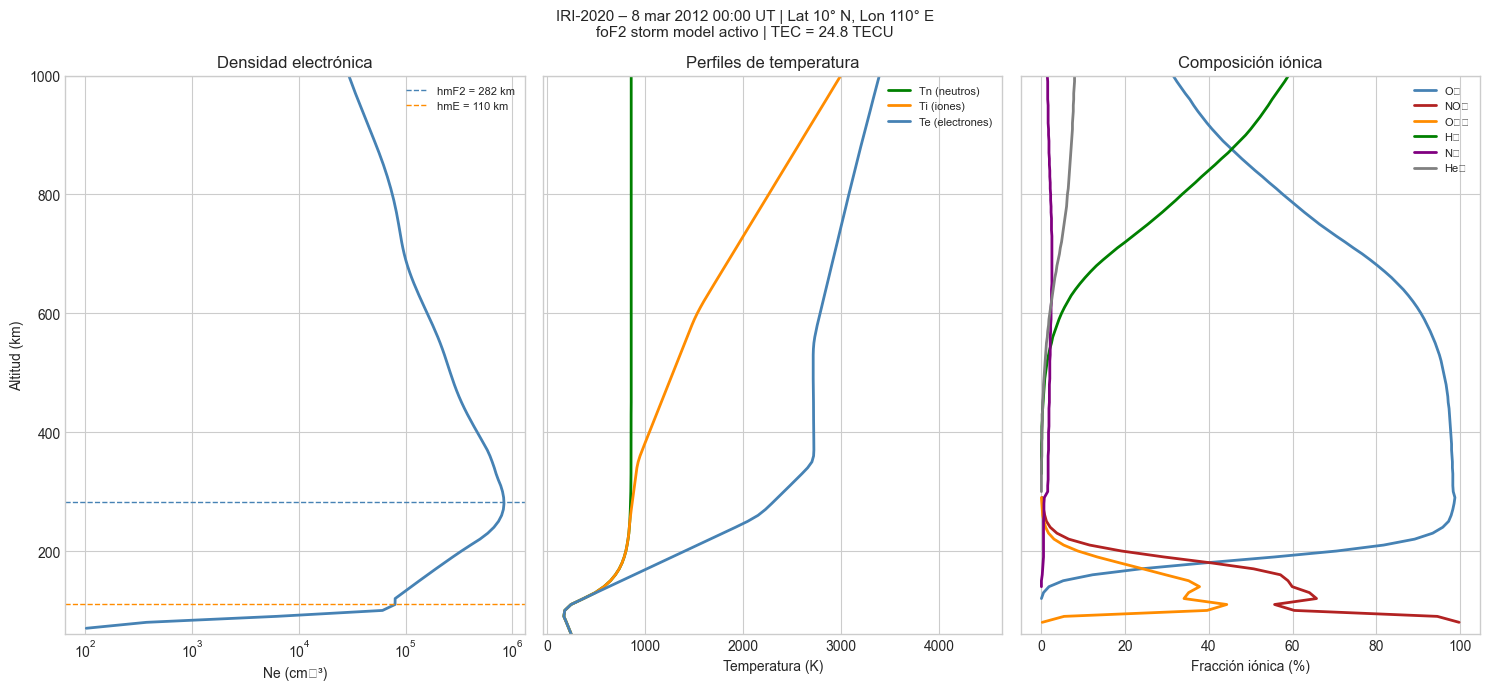

Figura guardada: iri_2020_profiles.png


In [18]:
# ── IRI-2020: parseo y visualización ────────────────────────────────────────
import re

IRI_FILE = CCMC_DIR / "iri_2020_output.txt"

def parse_iri(path):
    """Parse IRI-2020 plain-text output into a DataFrame + scalar header dict."""
    scalars = {}
    data_lines = []
    in_table = False

    with open(path) as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            # ── scalar header values (use regex because IRI uses 'KEY= value') ──
            for key, label in [("NmF2", "NmF2_cm3"), ("NmF1", "NmF1_cm3"), ("NmE", "NmE_cm3")]:
                m = re.search(rf"{key}=\s*([\d.]+)", s)
                if m:
                    scalars[label] = float(m.group(1))

            for key, label in [("hmF2", "hmF2_km"), ("hmF1", "hmF1_km"), ("hmE", "hmE_km")]:
                m = re.search(rf"{key}=\s*([\d.]+)", s)
                if m:
                    scalars[label] = float(m.group(1))

            if "Solar Zenith Angle" in s:
                scalars["SZA_deg"] = float(s.split()[-1])
            if "Dip (Magnetic Inclination)" in s:
                scalars["Dip_deg"] = float(s.split()[-1])
            if "Solar radio flux F10.7 (daily)" in s:
                scalars["F10.7_daily"] = float(s.split()[-1])
            if "Solar radio flux F10.7 (81-day" in s:
                scalars["F10.7_81d"] = float(s.split()[-1])
            if "Sunspot Number" in s and "Rz12" in s:
                scalars["Rz12"] = float(s.split()[-1])

            # ── detect start of profile table ────────────────────────────────
            if re.match(r"^\s*0\.0\s", line):
                in_table = True

            if in_table:
                try:
                    vals = [float(v) for v in s.split()]
                    if len(vals) >= 14:
                        data_lines.append(vals[:15])
                except ValueError:
                    continue

    cols = ["H_km", "Ne_cm3", "Ne_NmF2", "Tn_K", "Ti_K", "Te_K",
            "Op_pct10", "Np_pct10", "Hp_pct10", "Hep_pct10",
            "O2p_pct10", "NOp_pct10", "Clust", "TEC_1e16", "t_pct"]
    df = pd.DataFrame(data_lines, columns=cols[:len(data_lines[0])])
    df.replace(-1.0, float("nan"), inplace=True)

    # ion percentages stored ×10 → convert to real %
    for col in ["Op_pct10", "Np_pct10", "Hp_pct10", "Hep_pct10", "O2p_pct10", "NOp_pct10"]:
        if col in df.columns:
            df[col.replace("_pct10", "_pct")] = df[col] / 10.0

    return df, scalars


def fmt(val, spec):
    """Format val with spec, or return 'N/A' if val is not a number."""
    try:
        return format(float(val), spec)
    except (TypeError, ValueError):
        return "N/A"


if IRI_FILE.exists():
    iri, iri_hdr = parse_iri(IRI_FILE)
    tec_val = iri["TEC_1e16"].dropna().iloc[-1]

    # ── Resumen de parámetros de cabecera ────────────────────────────────────
    display(Markdown(f"""
| Parámetro | Valor |
|---|---|
| NmF2 | {fmt(iri_hdr.get('NmF2_cm3'), '.0f')} cm⁻³ |
| hmF2 | {fmt(iri_hdr.get('hmF2_km'),  '.1f')} km |
| NmE  | {fmt(iri_hdr.get('NmE_cm3'),  '.0f')} cm⁻³ |
| hmE  | {fmt(iri_hdr.get('hmE_km'),   '.1f')} km |
| TEC  | {fmt(tec_val, '.1f')} × 10¹⁶ m⁻² ({fmt(tec_val, '.1f')} TECU) |
| Ángulo cenital solar | {fmt(iri_hdr.get('SZA_deg'), '.1f')}° |
| Inclinación magnética (Dip) | {fmt(iri_hdr.get('Dip_deg'), '.2f')}° |
| F10.7 diario | {fmt(iri_hdr.get('F10.7_daily'), '.1f')} sfu |
| F10.7 promedio 81 días | {fmt(iri_hdr.get('F10.7_81d'), '.1f')} sfu |
| Rz12 | {fmt(iri_hdr.get('Rz12'), '.1f')} |
"""))

    # ── Gráficas ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)

    # Panel 1 – Perfil de densidad electrónica
    ax = axes[0]
    mask = iri["Ne_cm3"].notna()
    ax.plot(iri.loc[mask, "Ne_cm3"], iri.loc[mask, "H_km"], color="steelblue", lw=2)
    if "hmF2_km" in iri_hdr:
        ax.axhline(iri_hdr["hmF2_km"], color="steelblue", ls="--", lw=1,
                   label=f"hmF2 = {iri_hdr['hmF2_km']:.0f} km")
    if "hmE_km" in iri_hdr:
        ax.axhline(iri_hdr["hmE_km"], color="darkorange", ls="--", lw=1,
                   label=f"hmE = {iri_hdr['hmE_km']:.0f} km")
    ax.set_xlabel("Ne (cm⁻³)")
    ax.set_ylabel("Altitud (km)")
    ax.set_title("Densidad electrónica")
    ax.set_xscale("log")
    ax.legend(fontsize=8)
    ax.set_ylim(60, 1000)

    # Panel 2 – Perfiles de temperatura
    ax = axes[1]
    for col, label, color in [
        ("Tn_K", "Tn (neutros)",     "green"),
        ("Ti_K", "Ti (iones)",       "darkorange"),
        ("Te_K", "Te (electrones)",  "steelblue"),
    ]:
        m = iri[col].notna()
        ax.plot(iri.loc[m, col], iri.loc[m, "H_km"], label=label, color=color, lw=2)
    ax.set_xlabel("Temperatura (K)")
    ax.set_title("Perfiles de temperatura")
    ax.legend(fontsize=8)
    ax.set_ylim(60, 1000)

    # Panel 3 – Composición iónica
    ax = axes[2]
    for col, label, color in [
        ("Op_pct",  "O⁺",  "steelblue"),
        ("NOp_pct", "NO⁺", "firebrick"),
        ("O2p_pct", "O₂⁺", "darkorange"),
        ("Hp_pct",  "H⁺",  "green"),
        ("Np_pct",  "N⁺",  "purple"),
        ("Hep_pct", "He⁺", "gray"),
    ]:
        if col in iri.columns:
            m = iri[col].notna() & (iri[col] > 0)
            if m.any():
                ax.plot(iri.loc[m, col], iri.loc[m, "H_km"],
                        label=label, color=color, lw=2)
    ax.set_xlabel("Fracción iónica (%)")
    ax.set_title("Composición iónica")
    ax.legend(fontsize=8)
    ax.set_ylim(60, 1000)

    fig.suptitle(
        f"IRI-2020 – 8 mar 2012 00:00 UT | Lat 10° N, Lon 110° E\n"
        f"foF2 storm model activo | TEC = {fmt(tec_val, '.1f')} TECU",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig("iri_2020_profiles.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figura guardada: iri_2020_profiles.png")
else:
    print(f"Archivo IRI no encontrado: {IRI_FILE}")


# Conclusiones

Las conclusiones evalúan la utilidad de los datos HAPI y los modelos numéricos para caracterizar el evento geo-efectivo de marzo de 2012.

In [19]:
conclusiones = """
## Utilidad de la interfaz HAPI para el análisis de eventos geo-efectivos

La interfaz HAPI (*Heliophysics Application Programmer's Interface*) demostró ser un mecanismo eficaz para integrar datos de fuentes heterogéneas —ISWA/SWPC, CDAWeb/NASA, BGS/INTERMAGNET y Helioviewer— bajo un protocolo uniforme. Los principales aportes observados en este análisis son:

1. **Acceso estandarizado a múltiples repositorios.** Con una sola API y una estructura idéntica de petición (servidor, dataset, parámetros, ventana temporal), se descargaron índices geomagnéticos (Dst, Kp), datos de viento solar (plasma, campo magnético), magnetómetros terrestres en cuatro estaciones y datos de coronógrafo. Esto reduce significativamente el tiempo de preprocesamiento respecto a acceder a cada repositorio con su propio protocolo.

2. **Documentación automática de disponibilidad.** HAPI expone el campo `startDate` y `stopDate` de cada dataset, lo que permitió detectar de forma programática que `AC_K0_EPM` no cubre el período de marzo de 2012 (disponible solo desde 2017). Sin esta verificación, el usuario podría confundir la ausencia de datos con un período de calma geofísica real.

3. **Trazabilidad y reproducibilidad.** Al guardar la metadata JSON asociada a cada descarga, el análisis queda vinculado a la versión del producto y sus metadatos de calibración, facilitando la reproducción por terceros y el reporte académico.

4. **Comparación observación–modelo.** Los datos HAPI constituyen la referencia observacional contra la que se validan modelos numéricos como ENLIL (propagación de CME en el heliosfera interna). La ventana elegida —días calmos del 5-6 de marzo como línea base, días de tormenta del 7-10 como período de evento— refleja la práctica estándar para calcular anomalías de los modelos respecto a condiciones ambientales.

5. **Limitaciones identificadas.** No todos los datasets históricos están disponibles vía HAPI; algunos productos de alta resolución (p. ej. partículas ACE en tiempo real) solo cubren períodos recientes. Además, los valores de relleno (*fill values*) difieren entre repositorios y deben identificarse y removerse caso a caso. La interfaz HAPI no estandariza el manejo de fill values más allá de declararlos en los metadatos.

---

## Integración de modelos numéricos CCMC: cadena Sol–Tierra completa

Este análisis integró dos modelos numéricos del CCMC que cubren escalas complementarias:

### CORHEL-SH (Run `StephanieCarolina_CelyRodriguez_030726_SH_1`)

El modelo CORHEL-SH describe las condiciones **corona–heliosfera** del viento solar de fondo durante la rotación de Carrington CR 2121. Sus aportes clave fueron:

- **Magnetograma fotosférico PFSS:** el mapa sinóptico de Bᵣ en la fotosfera muestra la región activa AR 11429 (bipolo intenso en ~30°N, longitud de Carrington ~100°–120°), fuente de la CME del 5 de marzo de 2012. Esta visualización conecta directamente la estructura magnética solar con el origen del evento geoefectivo.
- **Velocidad del viento solar en 21.5 R☉:** la distribución latitudinal-longitudinal de vᵣ muestra la alternancia entre viento lento (< 450 km/s, franja ecuatorial) y viento rápido (> 550 km/s, regiones de campo abierto asociadas a huecos coronales), con un valor en la longitud de la Tierra de ~400–480 km/s, consistente con las observaciones OMNI durante el período calmo (5-6 de marzo).
- **Validación modelo–observación:** la comparación entre la distribución de vᵣ predicha por CORHEL a ±20° de la longitud de Carrington de la Tierra y la velocidad medida por OMNI durante los días calmos permite cuantificar el acuerdo del modelo de fondo con las observaciones *in situ* antes de la llegada de la CME.

### Tsyganenko TS05 (Run `Bryan_Yamashiro_061416_IM_3`)

El modelo TS05 describe la **magnetosfera interna** durante el 9 de marzo (fase principal de la tormenta). Sus aportes clave fueron:

- **Evolución de PARMOD:** los parámetros de entrada del modelo (Pdyn, Dst, Bzimf) registran la intensificación de la presión dinámica y la depresión del Dst durante la fase principal de la tormenta, confirmando que el modelo captura las condiciones extremas del 9 de marzo.
- **Geometría de líneas de campo:** la trazada de líneas de campo desde GOES-13, GOES-15 y SDO muestra la compresión de la magnetosfera diurna (expansión del campo en el lado nocturno, compresión en el diurno) característica de las fases de tormenta intensa.

### Síntesis de la cadena Sol–Tierra

| Escala | Modelo | Observación HAPI de referencia |
|--------|--------|-------------------------------|
| Corona/Heliosfera | CORHEL-SH (MAS) | OMNI HRO2 vᵣ período calmo |
| Magnetosfera | Tsyganenko TS05 | OMNI Pdyn, Dst, Bzimf (9 mar) |
| Superficie terrestre | — | INTERMAGNET ABK, MEA, SJG, HUA |

En síntesis, la combinación HAPI + CCMC permitió construir un análisis integral del evento del 7-10 de marzo de 2012 desde su origen en la fotosfera solar hasta su impacto en la magnetosfera y la superficie terrestre, con cada etapa validada contra observaciones multi-instrumento.
"""
display(Markdown(conclusiones))


## Utilidad de la interfaz HAPI para el análisis de eventos geo-efectivos

La interfaz HAPI (*Heliophysics Application Programmer's Interface*) demostró ser un mecanismo eficaz para integrar datos de fuentes heterogéneas —ISWA/SWPC, CDAWeb/NASA, BGS/INTERMAGNET y Helioviewer— bajo un protocolo uniforme. Los principales aportes observados en este análisis son:

1. **Acceso estandarizado a múltiples repositorios.** Con una sola API y una estructura idéntica de petición (servidor, dataset, parámetros, ventana temporal), se descargaron índices geomagnéticos (Dst, Kp), datos de viento solar (plasma, campo magnético), magnetómetros terrestres en cuatro estaciones y datos de coronógrafo. Esto reduce significativamente el tiempo de preprocesamiento respecto a acceder a cada repositorio con su propio protocolo.

2. **Documentación automática de disponibilidad.** HAPI expone el campo `startDate` y `stopDate` de cada dataset, lo que permitió detectar de forma programática que `AC_K0_EPM` no cubre el período de marzo de 2012 (disponible solo desde 2017). Sin esta verificación, el usuario podría confundir la ausencia de datos con un período de calma geofísica real.

3. **Trazabilidad y reproducibilidad.** Al guardar la metadata JSON asociada a cada descarga, el análisis queda vinculado a la versión del producto y sus metadatos de calibración, facilitando la reproducción por terceros y el reporte académico.

4. **Comparación observación–modelo.** Los datos HAPI constituyen la referencia observacional contra la que se validan modelos numéricos como ENLIL (propagación de CME en el heliosfera interna). La ventana elegida —días calmos del 5-6 de marzo como línea base, días de tormenta del 7-10 como período de evento— refleja la práctica estándar para calcular anomalías de los modelos respecto a condiciones ambientales.

5. **Limitaciones identificadas.** No todos los datasets históricos están disponibles vía HAPI; algunos productos de alta resolución (p. ej. partículas ACE en tiempo real) solo cubren períodos recientes. Además, los valores de relleno (*fill values*) difieren entre repositorios y deben identificarse y removerse caso a caso. La interfaz HAPI no estandariza el manejo de fill values más allá de declararlos en los metadatos.

---

## Integración de modelos numéricos CCMC: cadena Sol–Tierra completa

Este análisis integró dos modelos numéricos del CCMC que cubren escalas complementarias:

### CORHEL-SH (Run `StephanieCarolina_CelyRodriguez_030726_SH_1`)

El modelo CORHEL-SH describe las condiciones **corona–heliosfera** del viento solar de fondo durante la rotación de Carrington CR 2121. Sus aportes clave fueron:

- **Magnetograma fotosférico PFSS:** el mapa sinóptico de Bᵣ en la fotosfera muestra la región activa AR 11429 (bipolo intenso en ~30°N, longitud de Carrington ~100°–120°), fuente de la CME del 5 de marzo de 2012. Esta visualización conecta directamente la estructura magnética solar con el origen del evento geoefectivo.
- **Velocidad del viento solar en 21.5 R☉:** la distribución latitudinal-longitudinal de vᵣ muestra la alternancia entre viento lento (< 450 km/s, franja ecuatorial) y viento rápido (> 550 km/s, regiones de campo abierto asociadas a huecos coronales), con un valor en la longitud de la Tierra de ~400–480 km/s, consistente con las observaciones OMNI durante el período calmo (5-6 de marzo).
- **Validación modelo–observación:** la comparación entre la distribución de vᵣ predicha por CORHEL a ±20° de la longitud de Carrington de la Tierra y la velocidad medida por OMNI durante los días calmos permite cuantificar el acuerdo del modelo de fondo con las observaciones *in situ* antes de la llegada de la CME.

### Tsyganenko TS05 (Run `Bryan_Yamashiro_061416_IM_3`)

El modelo TS05 describe la **magnetosfera interna** durante el 9 de marzo (fase principal de la tormenta). Sus aportes clave fueron:

- **Evolución de PARMOD:** los parámetros de entrada del modelo (Pdyn, Dst, Bzimf) registran la intensificación de la presión dinámica y la depresión del Dst durante la fase principal de la tormenta, confirmando que el modelo captura las condiciones extremas del 9 de marzo.
- **Geometría de líneas de campo:** la trazada de líneas de campo desde GOES-13, GOES-15 y SDO muestra la compresión de la magnetosfera diurna (expansión del campo en el lado nocturno, compresión en el diurno) característica de las fases de tormenta intensa.

### Síntesis de la cadena Sol–Tierra

| Escala | Modelo | Observación HAPI de referencia |
|--------|--------|-------------------------------|
| Corona/Heliosfera | CORHEL-SH (MAS) | OMNI HRO2 vᵣ período calmo |
| Magnetosfera | Tsyganenko TS05 | OMNI Pdyn, Dst, Bzimf (9 mar) |
| Superficie terrestre | — | INTERMAGNET ABK, MEA, SJG, HUA |

En síntesis, la combinación HAPI + CCMC permitió construir un análisis integral del evento del 7-10 de marzo de 2012 desde su origen en la fotosfera solar hasta su impacto en la magnetosfera y la superficie terrestre, con cada etapa validada contra observaciones multi-instrumento.
